# CarePlus — Análise de Sinistralidade a partir de Laudos PDF

## Objetivo

Este notebook implementa um pipeline completo de análise de sinistralidade para operadoras de saúde, partindo de laudos laboratoriais em PDF e chegando a um modelo preditivo de risco.

O fluxo cobre três etapas principais:

1. **Geração de laudos sintéticos** — criação de PDFs realistas com variações de layout (Fleury, DASA, Pardini) e ruído proposital nos formatos de data, nomes de exames e unidades;
2. **Extração de entidades** — leitura dos PDFs, identificação de campos via coordenadas de coluna + regex, e exportação para Parquet;
3. **Análise e predição** — reprodução dos KPIs do OperadoraDashboard, feature engineering clínico, e treinamento de um **Random Forest** para classificação de risco de sinistro.

---

### Fórmulas clínicas utilizadas

| Métrica | Fórmula |
|---|---|
| **HOMA-IR** | `(glicemia × insulina) / 405` |
| **Framingham** | Score por pontos (sexo-específico) → risco CV 10 anos (%) |
| **Composite Score** | `sigmoid(8 × (raw − 0,42)) × 100 × confiança` onde `raw = 0,35·F + 0,25·H + 0,20·B + 0,20·M` |
| **Risco** | Alto ≥ 55 · Médio ≥ 28 · Baixo < 28 |

> `F` = Framingham normalizado · `H` = HOMA-IR normalizado · `B` = PAS normalizada · `M` = marcadores alterados / 7

In [1]:
# Instala dependências caso não estejam presentes
%pip install pdfplumber pandas pyarrow scikit-learn matplotlib seaborn tqdm reportlab numpy -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys, os, subprocess, warnings
from pathlib import Path
from math import exp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT   = Path('.').resolve()
LAUDOS_DIR     = PROJECT_ROOT / 'scripts' / 'laudos'
PARQUET_PATH   = PROJECT_ROOT / 'data' / 'laudos_sample.parquet'

# ── Paleta de cores — espelha o OperadoraDashboard ─────────────────────────────
HIGH    = '#F87171'   # alto risco
MED     = '#FBBF24'   # médio risco
LOW     = '#00D4A8'   # baixo risco
BLUE    = '#60A5FA'   # informativo
BG      = '#0B1120'   # fundo
SURFACE = '#111827'   # superfície
RAISED  = '#162032'   # elementos elevados
BORDER  = '#1e2d45'   # bordas
TEXT    = '#F1F5F9'   # texto
MUTED   = '#64748B'   # texto secundário

RISK_COLORS = {'alto': HIGH, 'medio': MED, 'baixo': LOW}
RISK_ORDER  = ['alto', 'medio', 'baixo']

# ── Tema global matplotlib ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':   BG,
    'axes.facecolor':     SURFACE,
    'axes.edgecolor':     BORDER,
    'axes.labelcolor':    TEXT,
    'axes.titlecolor':    TEXT,
    'axes.titleweight':   'bold',
    'axes.titlesize':     11,
    'text.color':         TEXT,
    'xtick.color':        MUTED,
    'ytick.color':        MUTED,
    'grid.color':         BORDER,
    'grid.alpha':         0.5,
    'grid.linewidth':     0.5,
    'legend.facecolor':   RAISED,
    'legend.edgecolor':   BORDER,
    'legend.labelcolor':  TEXT,
    'font.size':          9,
    'figure.dpi':         110,
    'savefig.facecolor':  BG,
})

def fmt_brl(v):
    """Formata valor monetário em pt-BR."""
    if v >= 1_000_000: return f'R$ {v/1_000_000:.1f}M'
    if v >= 1_000:     return f'R$ {v/1_000:.0f}K'
    return f'R$ {v:.0f}'

print(f'Python {sys.version.split()[0]}')
print(f'Projeto: {PROJECT_ROOT}')

Python 3.12.0
Projeto: C:\Users\pe\projetos\fiap\careplus-next\analises


---
## Parte 1 — Geração dos Laudos PDF

O script `scripts/gerar_laudos_pdf.py` produz laudos laboratoriais sintéticos em PDF, simulando os três principais laboratórios brasileiros (**Fleury**, **DASA**, **Pardini**) com variações propositais para desafiar pipelines de extração:

- Formatos de data: `DD/MM/AAAA`, `DD-MM-AAAA`, `DD de mês de AAAA`, `DD/MM/AA`, `AAAA-MM-DD`
- Nomes de exame: 5 variantes por marcador (ex.: `Glicemia de Jejum`, `Gli - Jejum 12h`, `Glicose (jejum)`)
- Unidades: `mg/dL` vs `mg%`; `µUI/mL` vs `μIU/mL`
- Interpretação clínica em linguagem natural gerada dinamicamente

Cada paciente é gerado com um **tier de risco** (alto/médio/baixo) que define os parâmetros estatísticos dos marcadores laboratoriais.

In [3]:
# ── Gerador de Laudos PDF — Funções (inline, sem subprocess) ─────────────────
import random, csv
from datetime import date as _date, datetime as _datetime, timedelta as _timedelta
from io import BytesIO

try:
    from reportlab.lib import colors as _rl_colors
    from reportlab.lib.pagesizes import A4 as _A4
    from reportlab.pdfgen import canvas as _rl_canvas
    from reportlab.platypus import Paragraph as _Paragraph
    from reportlab.lib.styles import ParagraphStyle as _ParagraphStyle
    from reportlab.lib.enums import TA_JUSTIFY as _TA_JUSTIFY
except ImportError:
    raise ImportError("pip install reportlab")

try:
    from tqdm import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False

# ── Dados clínicos ────────────────────────────────────────────────────────────
_NOMES_M = ['Alexandre','Bruno','Carlos','Daniel','Eduardo','Felipe','Gustavo','Henrique','Igor','João','Leandro','Marcelo','Nelson','Otávio','Pedro','Rafael','Sérgio','Thiago','Vitor','Wellington','André','Bernardo','Cláudio','Diego','Ernesto','Francisco','Gilberto','Hélio','Ivo','Jorge','Augusto','Caio','Davi','Emanuel','Fábio','Gabriel','Nilton','Orlando','Paulo','Renato','Saulo','Tiago','Valter','Wanderley','Xavier','Yuri']
_NOMES_F = ['Ana','Beatriz','Carla','Diana','Elisa','Fernanda','Gabriela','Helena','Isabela','Juliana','Karina','Lúcia','Mariana','Natália','Olívia','Patrícia','Roberta','Sandra','Tatiana','Vanessa','Adriana','Bruna','Cristina','Débora','Érica','Fátima','Giovanna','Irene','Jéssica','Keila','Larissa','Mônica','Nathalie','Paula','Renata','Solange','Telma','Vera','Yasmin','Aline','Bianca','Cecília','Danielle']
_SOBRENOMES = ['Silva','Santos','Oliveira','Souza','Rodrigues','Ferreira','Alves','Pereira','Lima','Gomes','Costa','Ribeiro','Martins','Carvalho','Almeida','Lopes','Fernandes','Vieira','Barbosa','Rocha','Dias','Nascimento','Andrade','Moreira','Nunes','Marques','Machado','Mendes','Freitas','Correia','Teixeira','Ramos','Cunha','Pinto','Azevedo','Melo','Monteiro','Cardoso','Cavalcante','Brito','Araújo','Leite']
_MEDICOS_PDF = [
    ('Ana Beatriz Costa','CRM/SP 87432','Endocrinologia'),('Carlos Eduardo Mendes','CRM/SP 54218','Cardiologia'),
    ('Fernanda Rocha Lima','CRM/MG 32109','Clínica Geral'),('Gustavo Alves Teixeira','CRM/SP 91045','Medicina Interna'),
    ('Helena Martins Pereira','CRM/RJ 67823','Nefrologia'),('João Pedro Barbosa','CRM/SP 48721','Clínica Médica'),
    ('Luciana Ferreira Melo','CRM/PR 22340','Endocrinologia'),('Marcos Vinícius Dias','CRM/SP 73156','Cardiologia'),
    ('Natália Souza Andrade','CRM/BA 19872','Medicina Preventiva'),('Rafael Rodrigues Nunes','CRM/SP 60934','Medicina Interna'),
    ('Sandra Oliveira Cunha','CRM/RS 35421','Clínica Geral'),('Thiago Carvalho Moreira','CRM/SP 81267','Geriatria'),
]
_CIDADES_PDF = [
    ('São Paulo','SP','01310-100'),('Rio de Janeiro','RJ','20040-020'),('Belo Horizonte','MG','30130-110'),
    ('Curitiba','PR','80010-020'),('Porto Alegre','RS','90010-150'),('Salvador','BA','40020-000'),
    ('Campinas','SP','13010-040'),('Ribeirão Preto','SP','14010-931'),
    ('São Bernardo do Campo','SP','09710-001'),('Florianópolis','SC','88010-500'),
]
_CID10_PDF = {
    'alto':  [('E11.9','Diabetes mellitus tipo 2, sem complicações'),('I10','Hipertensão essencial (primária)'),('E78.5','Hiperlipidemia mista'),('E66.9','Obesidade não especificada'),('I25.9','Doença isquêmica crônica do coração'),('N18.3','Doença renal crônica, estágio 3')],
    'medio': [('E11.9','Diabetes mellitus tipo 2'),('I10','Hipertensão arterial sistêmica'),('E78.0','Hipercolesterolemia pura'),('E66.0','Obesidade devida a excesso de calorias'),('J45.9','Asma não especificada'),('F32.0','Episódio depressivo leve')],
    'baixo': [('Z00.0','Exame médico geral'),('Z13.6','Rastreamento de doenças cardiovasculares'),('J06.9','Infecção aguda das vias aéreas superiores'),('K29.7','Gastrite não especificada'),('Z82.4','História familiar de doença isquêmica do coração')],
}
_LABS_PDF = [
    {'name':'Laboratório Fleury','short':'FLEURY','cnpj':'60.840.055/0001-31','cnes':'2077472','crm_resp':'Dra. Marcia Tavares — CRF/SP 15.234','color':_rl_colors.HexColor('#003F7F'),'accent':_rl_colors.HexColor('#00AEEF'),'address':'Av. General Waldomiro de Lima, 508 — Jabaquara — São Paulo/SP','phone':'(11) 3179-0000','site':'www.fleury.com.br'},
    {'name':'Diagnósticos da América (DASA)','short':'DASA','cnpj':'61.486.650/0001-83','cnes':'3526180','crm_resp':'Dr. Paulo Riccio — CRF/SP 22.891','color':_rl_colors.HexColor('#C0392B'),'accent':_rl_colors.HexColor('#E74C3C'),'address':'Rua Adolfo Lutz, 108 — Santa Cecília — São Paulo/SP','phone':'0800 722 3272','site':'www.dasa.com.br'},
    {'name':'Hermes Pardini','short':'PARDINI','cnpj':'19.378.769/0001-76','cnes':'6921504','crm_resp':'Dra. Cristiane Mendonça — CRF/MG 8.445','color':_rl_colors.HexColor('#1E8449'),'accent':_rl_colors.HexColor('#27AE60'),'address':'Rua Aimorés, 66 — Funcionários — Belo Horizonte/MG','phone':'(31) 3228-6200','site':'www.hermespardini.com.br'},
]
_EXAM_NAMES_PDF = {
    'glucose':       ['Glicemia de Jejum','Glicose (jejum)','Glicose de Jejum','Gli - Jejum 12h','Glicemia Plasmática em Jejum'],
    'insulin':       ['Insulina Basal','Insulina de Jejum','Insulina (basal)','Insulina Plasmática','Ins - Jejum'],
    'total_chol':    ['Colesterol Total','Colesterol - Total','Colest. Total','CT - Colesterol Total','Lipídios - Colesterol Total'],
    'ldl':           ['LDL Colesterol','LDL-Colesterol (Friedewald)','LDL-C','Colesterol LDL','LDL Col. (calculado)'],
    'hdl':           ['HDL Colesterol','HDL-Colesterol','HDL-C','Colesterol HDL','HDL Col.'],
    'triglycerides': ['Triglicerídeos','Triglicérides','TG - Triglicerídeos','Triglicérides (Enzimático)','Lipídios - Triglicerídeos'],
    'homa_ir':       ['HOMA-IR','HOMA IR (Insulino-resistência)','Índice HOMA-IR','Resistência Insulínica - HOMA','HOMA-IR (calculado)'],
    'sys_bp':        ['Pressão Arterial Sistólica','PAS','Pressão Sistólica (mmHg)','PA Sistólica','Pressão Arterial — Sistólica'],
    'dia_bp':        ['Pressão Arterial Diastólica','PAD','Pressão Diastólica (mmHg)','PA Diastólica','Pressão Arterial — Diastólica'],
}
_UNITS_PDF = {
    'glucose':['mg/dL','mg/dL','mg%'],'insulin':['µUI/mL','uUI/mL','µU/mL','μIU/mL'],
    'total_chol':['mg/dL','mg/dL','mg%'],'ldl':['mg/dL','mg/dL','mg%'],
    'hdl':['mg/dL','mg/dL','mg%'],'triglycerides':['mg/dL','mg/dL','mg%'],
    'homa_ir':['—','adimensional',''],'sys_bp':['mmHg','mm Hg','mmHg'],'dia_bp':['mmHg','mm Hg','mmHg'],
}
_REF_RANGES_PDF = {
    'glucose':      ('Desejável: < 100\nPré-diabetes: 100–125\nDiabetes: ≥ 126', lambda v,s: v > 99),
    'insulin':      ('Valor de referência: < 25 µUI/mL',                          lambda v,s: v > 25),
    'total_chol':   ('Desejável: < 200\nLimítrofe: 200–239\nAlto: ≥ 240',        lambda v,s: v >= 200),
    'ldl':          ('Ótimo: < 100\nDesejável: 100–129\nLimítrofe: 130–159\nAlto: ≥ 160', lambda v,s: v >= 130),
    'hdl':          ('Baixo risco: ≥ 60\nRisco: < 40 (M) / < 50 (F)',             lambda v,s: v < (50 if s=='F' else 40)),
    'triglycerides':('Desejável: < 150\nLimítrofe: 150–199\nAlto: ≥ 200',        lambda v,s: v >= 150),
    'homa_ir':      ('Normal: < 2,5\nResistência insulínica: ≥ 2,5',              lambda v,s: v >= 2.5),
    'sys_bp':       ('Normal: < 120\nElevada: 120–129\nHAS estágio 1: 130–139',  lambda v,s: v >= 130),
    'dia_bp':       ('Normal: < 80\nHAS estágio 1: 80–89\nHAS estágio 2: ≥ 90',  lambda v,s: v >= 80),
}
_MESES_PT_PDF = ['janeiro','fevereiro','março','abril','maio','junho','julho','agosto','setembro','outubro','novembro','dezembro']

# ── Dimensões do PDF ──────────────────────────────────────────────────────────
_PW, _PH = _A4
_pt = 1
_MX = 40 * _pt
_MY = 28 * _pt
_CW = _PW - 2 * _MX
_CB = _rl_colors.HexColor('#1A1A1A'); _CG = _rl_colors.HexColor('#555555')
_CLG = _rl_colors.HexColor('#EEEEEE'); _CMG = _rl_colors.HexColor('#CCCCCC')
_CR  = _rl_colors.HexColor('#C0392B'); _CGR = _rl_colors.HexColor('#1E8449')
_CW2 = _rl_colors.white

# ── Funções auxiliares ────────────────────────────────────────────────────────
def _clamp_v(v, lo, hi): return max(lo, min(hi, v))
def _gauss_v(rng, mean, std, lo=-1e9, hi=1e9): return float(np.clip(rng.normal(mean, std), lo, hi))

def _calc_homa(glucose, insulin): return round((glucose * insulin) / 405, 2)

def _calc_fram(age, sex, tc, hdl, sbp, smoker, diabetic):
    if sex == 'M':
        pts = (-1 if age<35 else 0 if age<40 else 1 if age<45 else 2 if age<50 else 3 if age<55 else 4 if age<60 else 5 if age<65 else 6 if age<70 else 7)
        pts += -3 if tc<160 else 0 if tc<200 else 1 if tc<240 else 2 if tc<280 else 3
        pts += 2 if hdl<35 else 1 if hdl<45 else 0 if hdl<50 else -1 if hdl<60 else -2
        pts += -3 if sbp<120 else 0 if sbp<130 else 1 if sbp<140 else 2 if sbp<160 else 3
        if smoker: pts += 2
        if diabetic: pts += 2
        return [1,2,2,3,4,4,6,7,9,11,14,18,22,27,33,40,47,56][int(_clamp_v(pts+3,0,17))]
    else:
        pts = (-9 if age<35 else -4 if age<40 else 0 if age<45 else 3 if age<50 else 6 if age<55 else 7 if age<60 else 8)
        pts += -2 if tc<160 else 0 if tc<200 else 1 if tc<240 else 2 if tc<280 else 3
        pts += 5 if hdl<35 else 2 if hdl<45 else 1 if hdl<50 else 0 if hdl<60 else -2
        pts += -3 if sbp<120 else 0 if sbp<130 else 1 if sbp<140 else 2 if sbp<160 else 3
        if smoker: pts += 2
        if diabetic: pts += 4
        return [1,2,2,3,3,4,5,6,7,8,9,11,13,15,17,20,24,27,32][int(_clamp_v(pts+2,0,18))]

def _fmt_dt(d, style):
    if style == 0: return d.strftime('%d/%m/%Y')
    if style == 1: return d.strftime('%d-%m-%Y')
    if style == 2: return f'{d.day} de {_MESES_PT_PDF[d.month-1]} de {d.year}'
    if style == 3: return d.strftime('%d/%m/%y')
    return d.strftime('%Y-%m-%d')

def generate_patient_exam(seed, ref_date):
    rng = np.random.default_rng(seed); py = random.Random(seed)
    tier = py.choices(['alto','medio','baixo'], weights=[0.30,0.40,0.30])[0]
    sex  = 'M' if rng.random() > 0.52 else 'F'
    age  = int(_clamp_v(_gauss_v(rng, {'alto':58,'medio':47,'baixo':36}[tier], 9), 25, 78))
    smk  = rng.random() < {'alto':0.55,'medio':0.25,'baixo':0.08}[tier]
    dia  = rng.random() < {'alto':0.58,'medio':0.22,'baixo':0.04}[tier]
    p = {'alto':dict(gM=140,iM=22,tcM=248,ldlM=168,hdlM=33 if sex=='M' else 42,tgM=225,sysM=152,diaM=95),
         'medio':dict(gM=106,iM=13,tcM=215,ldlM=138,hdlM=42 if sex=='M' else 51,tgM=158,sysM=134,diaM=84),
         'baixo':dict(gM=88,iM=7,tcM=178,ldlM=105,hdlM=54 if sex=='M' else 62,tgM=105,sysM=116,diaM=74)}[tier]
    gl=round(_clamp_v(_gauss_v(rng,p['gM'],12),60,310)); ins=round(_clamp_v(_gauss_v(rng,p['iM'],3),1,60),1)
    tc=round(_clamp_v(_gauss_v(rng,p['tcM'],18),100,360)); ldl=round(_clamp_v(_gauss_v(rng,p['ldlM'],15),40,260))
    hdl=round(_clamp_v(_gauss_v(rng,p['hdlM'],7),15,105)); tg=round(_clamp_v(_gauss_v(rng,p['tgM'],25),40,510))
    sbp=round(_clamp_v(_gauss_v(rng,p['sysM'],10),88,225)); dbp=round(_clamp_v(_gauss_v(rng,p['diaM'],8),55,135))
    homa=_calc_homa(gl,ins); fram=_calc_fram(age,sex,tc,hdl,sbp,smk,dia)
    birth=_date(ref_date.year-age, py.randint(1,12), py.randint(1,28))
    name=f"{py.choice(_NOMES_M if sex=='M' else _NOMES_F)} {py.choice(_SOBRENOMES)}"
    cd=[py.randint(0,9) for _ in range(9)]; s1=sum((10-i)*v for i,v in enumerate(cd))%11; cd.append(0 if s1<2 else 11-s1)
    s2=sum((11-i)*v for i,v in enumerate(cd))%11; cd.append(0 if s2<2 else 11-s2)
    cpf=f'{"".join(map(str,cd[:3]))}.{"".join(map(str,cd[3:6]))}.{"".join(map(str,cd[6:9]))}-{"".join(map(str,cd[9:]))}'
    city,state,cep=py.choice(_CIDADES_PDF); doc=py.choice(_MEDICOS_PDF); lab=py.choice(_LABS_PDF)
    cid_c,cid_d=py.choice(_CID10_PDF[tier])
    exam_date=ref_date-_timedelta(days=py.randint(1,365)); ch=py.randint(6,10); cm=py.choice([0,15,30,45])
    rep=_datetime(exam_date.year,exam_date.month,exam_date.day,ch+py.randint(2,6),py.randint(0,59))
    proto=f"{lab['short'][:3]}{exam_date.strftime('%Y%m%d')}{seed:06d}"
    return {'seed':seed,'tier':tier,'patient_id':f'P{seed:08d}','name':name,'age':age,'sex':sex,
            'birth_date':birth,'cpf':cpf,'city':city,'state':state,'cep':cep,
            'doctor_name':doc[0],'doctor_crm':doc[1],'doctor_spec':doc[2],
            'cid_code':cid_c,'cid_desc':cid_d,'lab':lab,
            'exam_date':exam_date,'collect_time':f'{ch:02d}:{cm:02d}','report_dt':rep,'protocol':proto,
            'smoker':smk,'diabetic':dia,'glucose':gl,'insulin':ins,'total_chol':tc,'ldl':ldl,
            'hdl':hdl,'triglycerides':tg,'homa_ir':homa,'sys_bp':sbp,'dia_bp':dbp,'framingham':fram}

def _build_interp(d, py):
    f=[]; st='paciente' if py.random()>0.5 else ('o paciente' if d['sex']=='M' else 'a paciente')
    if d['glucose']>125: f.append(f"glicemia de jejum elevada ({d['glucose']} mg/dL), compatível com diabetes mellitus")
    elif d['glucose']>99: f.append(f"glicemia em nível pré-diabético ({d['glucose']} mg/dL)")
    if d['homa_ir']>=2.5: f.append(f"índice HOMA-IR de {d['homa_ir']}, indicando resistência insulínica")
    if d['total_chol']>=240: f.append(f"hipercolesterolemia (CT={d['total_chol']} mg/dL)")
    elif d['total_chol']>=200: f.append(f"colesterol total limítrofe ({d['total_chol']} mg/dL)")
    if d['ldl']>=160: f.append(f"LDL elevado ({d['ldl']} mg/dL)")
    elif d['ldl']>=130: f.append(f"LDL limítrofe ({d['ldl']} mg/dL)")
    if d['hdl']<(50 if d['sex']=='F' else 40): f.append(f"HDL abaixo do desejável ({d['hdl']} mg/dL)")
    if d['triglycerides']>=200: f.append(f"hipertrigliceridemia ({d['triglycerides']} mg/dL)")
    elif d['triglycerides']>=150: f.append(f"triglicerídeos limítrofes ({d['triglycerides']} mg/dL)")
    if d['sys_bp']>=140: f.append(f"HAS estágio 2 (PA={d['sys_bp']}/{d['dia_bp']} mmHg)")
    elif d['sys_bp']>=130: f.append(f"HAS estágio 1 (PA={d['sys_bp']}/{d['dia_bp']} mmHg)")
    if not f: return py.choice(["Exames dentro dos limites de referência. Acompanhamento periódico recomendado.",
                                "Perfil metabólico sem alterações significativas. Manter hábitos saudáveis."])
    text=f[0]
    for i in range(1,len(f)): text+=(py.choice([', ','; ',' e ']) if i<len(f)-1 else ' e ')+f[i]
    op=py.choice([f"O perfil do {st} evidencia ","A análise demonstra ","Os exames revelam "])
    cl=py.choice([" Recomenda-se avaliação clínica complementar.",f" Seguimento com {d['doctor_spec'].lower()} recomendado.",
                  " Correlacionar com quadro clínico."])
    return op+text+"."+cl

def _barcode(c,x,y,w,h,py):
    bx=x
    while bx<x+w-2:
        bw=py.choice([1,1,1,2,3])*_pt
        if py.random()>0.4: c.setFillColor(_CB); c.rect(bx,y,bw,h,stroke=0,fill=1)
        bx+=bw+py.choice([0.5,1,1.5])*_pt
    c.setFillColor(_CB)

def render_laudo(data, py):
    buf=BytesIO(); lab=data['lab']
    c=_rl_canvas.Canvas(buf,pagesize=_A4); c.setTitle(f"Laudo — {data['protocol']}")
    y=_PH-_MY
    hh=58*_pt; c.setFillColor(lab['color']); c.rect(0,_PH-hh,_PW,hh,stroke=0,fill=1)
    c.setFillColor(lab['accent']); c.rect(0,_PH-hh-4*_pt,_PW,4*_pt,stroke=0,fill=1)
    c.setFillColor(_CW2); c.setFont('Helvetica-Bold',18); c.drawString(_MX,_PH-26*_pt,lab['name'].upper())
    c.setFont('Helvetica',8); c.drawString(_MX,_PH-38*_pt,'RESULTADO DE EXAMES LABORATORIAIS')
    c.setFont('Helvetica',7); rx=_PW-_MX
    for i,ln in enumerate([f"CNPJ: {lab['cnpj']}",f"CNES: {lab['cnes']}",lab['phone'],lab['site']]):
        c.drawRightString(rx,_PH-16*_pt-i*9*_pt,ln)
    y=_PH-hh-8*_pt; c.setFillColor(_CG); c.setFont('Helvetica',7); c.drawString(_MX,y,lab['address']); y-=16*_pt
    c.setFillColor(lab['color']); c.setFont('Helvetica-Bold',10); c.drawString(_MX,y,'LAUDO LABORATORIAL')
    c.setFont('Helvetica',8); c.setFillColor(_CG)
    c.drawRightString(_PW-_MX,y,f"Protocolo: {data['protocol']}   |   Emissão: {_fmt_dt(data['exam_date'],py.randint(0,4))}")
    y-=4*_pt; c.setStrokeColor(lab['color']); c.setLineWidth(0.8); c.line(_MX,y,_PW-_MX,y); y-=10*_pt

    def sec(txt,yp):
        c.setFillColor(_CLG); c.rect(_MX,yp-2*_pt,_CW,14*_pt,stroke=0,fill=1)
        c.setFillColor(lab['color']); c.setFont('Helvetica-Bold',8); c.drawString(_MX+4*_pt,yp+3*_pt,txt.upper())
        return yp-16*_pt
    def kv(lbl,val,x,yp,fs=8):
        c.setFont('Helvetica-Bold',fs); c.setFillColor(_CG); c.drawString(x,yp,f'{lbl}:')
        c.setFont('Helvetica',fs); c.setFillColor(_CB); c.drawString(x+c.stringWidth(f'{lbl}: ','Helvetica-Bold',fs),yp,val)

    y=sec('Dados do Paciente',y); y-=3*_pt
    col2=_MX+_CW/2; sx='Masculino' if data['sex']=='M' else 'Feminino'; bs=_fmt_dt(data['birth_date'],py.randint(0,2))
    kv('Paciente',data['name'],_MX,y); kv('Sexo',sx,col2,y); y-=12*_pt
    kv('Data de Nasc.',bs,_MX,y); kv('Idade',f"{data['age']} anos",col2,y); y-=12*_pt
    kv('CPF',data['cpf'],_MX,y); kv('CID-10',f"{data['cid_code']} — {data['cid_desc'][:38]}",col2,y); y-=12*_pt
    kv('Município',f"{data['city']}/{data['state']} — CEP {data['cep']}",_MX,y); y-=14*_pt
    c.setStrokeColor(_CMG); c.setLineWidth(0.4); c.line(_MX,y,_PW-_MX,y); y-=10*_pt

    y=sec('Dados da Requisição',y); y-=3*_pt
    cs=f"{_fmt_dt(data['exam_date'],py.randint(0,3))} às {data['collect_time']}h"
    kv('Médico Solicitante',data['doctor_name'],_MX,y); kv('CRM',data['doctor_crm'],col2,y); y-=12*_pt
    kv('Especialidade',data['doctor_spec'],_MX,y); kv('Data de Coleta',cs,col2,y); y-=12*_pt
    kv('Material',py.choice(['Sangue venoso — soro (jejum de 12 horas)','Sangue venoso — plasma EDTA (jejum ≥ 8h)','Sangue venoso — soro (jejum de 10 a 12h)']),_MX,y); y-=16*_pt

    c.setStrokeColor(_CMG); c.line(_MX,y,_PW-_MX,y); y-=2*_pt
    y=sec('Resultado dos Exames',y); y-=4*_pt
    cx=[0,185*_pt,270*_pt,320*_pt,420*_pt]
    c.setFillColor(lab['color']); c.rect(_MX,y-3*_pt,_CW,14*_pt,stroke=0,fill=1)
    c.setFillColor(_CW2); c.setFont('Helvetica-Bold',7)
    for ci,cl in enumerate(['EXAME','RESULTADO','UNIDADE','VALOR DE REFERÊNCIA','INTERP.']):
        c.drawString(_MX+cx[ci]+3*_pt,y+2*_pt,cl)
    y-=16*_pt; rh=24*_pt
    for idx,(key,val,dec) in enumerate([('glucose',data['glucose'],2),('insulin',data['insulin'],1),
        ('total_chol',data['total_chol'],0),('ldl',data['ldl'],0),('hdl',data['hdl'],0),
        ('triglycerides',data['triglycerides'],0),('homa_ir',data['homa_ir'],2),
        ('sys_bp',data['sys_bp'],0),('dia_bp',data['dia_bp'],0)]):
        rt,afn=_REF_RANGES_PDF[key]; ia=afn(val,data['sex'])
        c.setFillColor(_rl_colors.HexColor('#F7F9FC') if idx%2==0 else _CW2)
        c.rect(_MX,y-2*_pt,_CW,rh,stroke=0,fill=1)
        if ia: c.setFillColor(_CR); c.rect(_MX,y-2*_pt,3*_pt,rh,stroke=0,fill=1)
        el=py.choice(_EXAM_NAMES_PDF[key]); ul=py.choice(_UNITS_PDF[key]); vs=f'{val:.{dec}f}'
        sym='↓ Baixo' if key=='hdl' and ia else ('↑ Alto' if ia else 'Normal')
        c.setFont('Helvetica',8); c.setFillColor(_CB); c.drawString(_MX+cx[0]+5*_pt,y+7*_pt,el)
        c.setFont('Helvetica-Bold',9); c.setFillColor(_CR if ia else _CB); c.drawString(_MX+cx[1]+3*_pt,y+7*_pt,vs)
        c.setFont('Helvetica',8); c.setFillColor(_CG); c.drawString(_MX+cx[2]+3*_pt,y+7*_pt,ul)
        c.setFont('Helvetica',6); c.setFillColor(_CG)
        for li,rl in enumerate(rt.split('\n')[:2]): c.drawString(_MX+cx[3]+3*_pt,y+rh-9*_pt-li*7*_pt,rl)
        c.setFont('Helvetica-Bold',8); c.setFillColor(_CR if ia else _CGR); c.drawString(_MX+cx[4]+3*_pt,y+7*_pt,sym)
        c.setStrokeColor(_CMG); c.setLineWidth(0.3); c.line(_MX,y-2*_pt,_PW-_MX,y-2*_pt); y-=rh
    y-=6*_pt
    c.setStrokeColor(_CMG); c.line(_MX,y,_PW-_MX,y); y-=2*_pt
    y=sec('Interpretação Clínica',y); y-=6*_pt
    ip=_build_interp(data,py)
    sty=_ParagraphStyle('i',fontName='Helvetica',fontSize=8,leading=12,textColor=_CB,alignment=_TA_JUSTIFY,leftIndent=4,rightIndent=4)
    par=_Paragraph(ip,sty); pw,ph=par.wrapOn(c,_CW-8*_pt,200*_pt); par.drawOn(c,_MX+4*_pt,y-ph); y-=ph+12*_pt
    c.setFont('Helvetica-Oblique',7); c.setFillColor(_CG)
    c.drawString(_MX+4*_pt,y,f'Risco cardiovascular em 10 anos (Escore de Framingham): {data["framingham"]}%'); y-=18*_pt
    fy=_MY+40*_pt; c.setStrokeColor(lab['color']); c.setLineWidth(0.6)
    c.line(_MX,fy+30*_pt,_MX+120*_pt,fy+30*_pt)
    c.setFont('Helvetica-Bold',7); c.setFillColor(_CB); c.drawString(_MX,fy+22*_pt,'RESPONSÁVEL TÉCNICO')
    c.setFont('Helvetica',7); c.drawString(_MX,fy+13*_pt,lab['crm_resp'])
    c.setFillColor(_CG); c.drawString(_MX,fy+4*_pt,f"Emitido em: {_fmt_dt(data['report_dt'].date(),0)} às {data['report_dt'].strftime('%H:%M')}   |   Validade: 90 dias.")
    bx=_PW-_MX-110*_pt; _barcode(c,bx,fy+8*_pt,110*_pt,20*_pt,py)
    c.setFont('Helvetica',6); c.setFillColor(_CB); c.drawCentredString(bx+55*_pt,fy+2*_pt,data['protocol'])
    c.setStrokeColor(lab['accent']); c.setLineWidth(2); c.line(0,_MY,_PW,_MY)
    c.setFillColor(lab['color']); c.setFont('Helvetica',6)
    c.drawCentredString(_PW/2,_MY-8*_pt,f"{lab['name']} — {lab['address']} — {lab['phone']}")
    c.save(); return buf.getvalue()

print('✓ Funções de geração de laudos PDF carregadas')

✓ Funções de geração de laudos PDF carregadas


In [4]:
# Gera laudos PDF diretamente (sem subprocess) — pula se já existirem
# Ajuste N_LAUDOS conforme necessário (500 = rápido, 5000 = dataset completo)
N_LAUDOS = 500

pdf_count = len(list(LAUDOS_DIR.glob('**/*.pdf'))) if LAUDOS_DIR.exists() else 0

if pdf_count == 0:
    print(f'Gerando {N_LAUDOS} laudos PDF em {LAUDOS_DIR}...')
    LAUDOS_DIR.mkdir(parents=True, exist_ok=True)

    REF_DATE   = _date(2026, 5, 25)
    seeds      = list(range(42, 42 + N_LAUDOS))
    index_rows = []

    iterator = tqdm(seeds, desc='Gerando PDFs', unit='pdf') if HAS_TQDM else seeds
    for seed in iterator:
        py_rng    = random.Random(seed)
        data      = generate_patient_exam(seed, REF_DATE)
        pdf_bytes = render_laudo(data, py_rng)

        subdir = LAUDOS_DIR / f'P{seed:08d}'
        subdir.mkdir(parents=True, exist_ok=True)
        path   = subdir / f'{data["protocol"]}.pdf'
        path.write_bytes(pdf_bytes)

        index_rows.append({
            'file': str(path.relative_to(LAUDOS_DIR)), 'protocol': data['protocol'],
            'patient_id': data['patient_id'], 'patient': data['name'],
            'exam_date': data['exam_date'].isoformat(), 'tier': data['tier'],
            'lab': data['lab']['short'], 'glucose': data['glucose'],
            'insulin': data['insulin'], 'total_chol': data['total_chol'],
            'ldl': data['ldl'], 'hdl': data['hdl'],
            'triglycerides': data['triglycerides'], 'homa_ir': data['homa_ir'],
            'sys_bp': data['sys_bp'], 'dia_bp': data['dia_bp'], 'framingham': data['framingham'],
        })

    # Salva índice CSV (ground truth para avaliação do extractor)
    index_path = LAUDOS_DIR / 'index.csv'
    with open(index_path, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=list(index_rows[0].keys()))
        w.writeheader(); w.writerows(index_rows)

    pdf_count = len(list(LAUDOS_DIR.glob('**/*.pdf')))
    print(f'\n✓ {pdf_count:,} laudos gerados | Índice: {index_path}')

from collections import Counter
labs_dist = Counter(p.stem[:3] for p in LAUDOS_DIR.glob('**/*.pdf'))
print(f'\n✓ {pdf_count:,} laudos encontrados em {LAUDOS_DIR}')
print('  Distribuição por laboratório:')
for lab_name, n in sorted(labs_dist.items(), key=lambda x: -x[1]):
    print(f'    {lab_name}: {n:,}  ({n/pdf_count*100:.1f}%)')

Gerando 500 laudos PDF em C:\Users\pe\projetos\fiap\careplus-next\analises\scripts\laudos...


Gerando PDFs:   0%|          | 0/500 [00:00<?, ?pdf/s]

Gerando PDFs:   3%|▎         | 14/500 [00:00<00:03, 131.64pdf/s]

Gerando PDFs:   6%|▌         | 28/500 [00:00<00:03, 134.12pdf/s]

Gerando PDFs:   8%|▊         | 42/500 [00:00<00:03, 135.55pdf/s]

...

Gerando PDFs:  92%|█████████▏| 460/500 [00:03<00:00, 136.19pdf/s]

Gerando PDFs:  95%|█████████▍| 474/500 [00:03<00:00, 136.43pdf/s]

Gerando PDFs:  98%|█████████▊| 488/500 [00:03<00:00, 135.53pdf/s]

Gerando PDFs: 100%|██████████| 500/500 [00:03<00:00, 131.87pdf/s]


✓ 500 laudos gerados | Índice: C:\Users\pe\projetos\fiap\careplus-next\analises\scripts\laudos\index.csv

✓ 500 laudos encontrados em C:\Users\pe\projetos\fiap\careplus-next\analises\scripts\laudos
  Distribuição por laboratório:
    DAS: 178  (35.6%)
    FLE: 170  (34.0%)
    PAR: 152  (30.4%)


---
## Parte 2 — Extração de Entidades para Parquet

O script `scripts/extrair_laudos_parquet.py` faz a extração em duas etapas:

1. **Coordenadas de coluna** — a tabela de resultados usa posições x fixas (derivadas do layout do reportlab). Cada linha da tabela é identificada pelo bucket de y dos termos na coluna de exame, e o valor numérico + unidade são lidos nas colunas correspondentes.

2. **Regex nos campos textuais** — nome do paciente, CPF, CID-10, médico solicitante, datas de coleta (todos os 5 formatos), Framingham.

Um **fallback de regex** no texto corrido garante cobertura de 100% mesmo quando o agrupamento por coordenadas falha.

| Campo | Estratégia |
|---|---|
| Valores laboratoriais | Coordenadas x + y |
| Nome, CPF, CID | Regex com captura entre rótulos |
| Datas | Parser multi-formato (5 padrões) |
| Metadados | Nome de arquivo (lab_short, patient_id, exam_date) |

In [5]:
# ── Extrator de Laudos PDF — Funções (inline, sem subprocess) ────────────────
import re
from datetime import date as _date_ext

try:
    import pdfplumber
except ImportError:
    raise ImportError("pip install pdfplumber")

_EXAM_ALIASES = {
    'glucose':       ['Glicemia de Jejum','Glicose (jejum)','Glicose de Jejum','Gli - Jejum 12h','Glicemia Plasmática em Jejum'],
    'insulin':       ['Insulina Basal','Insulina de Jejum','Insulina (basal)','Insulina Plasmática','Ins - Jejum'],
    'total_chol':    ['Colesterol Total','Colesterol - Total','Colest. Total','CT - Colesterol Total','Lipídios - Colesterol Total'],
    'ldl':           ['LDL Colesterol','LDL-Colesterol (Friedewald)','LDL-C','Colesterol LDL','LDL Col. (calculado)'],
    'hdl':           ['HDL Colesterol','HDL-Colesterol','HDL-C','Colesterol HDL','HDL Col.'],
    'triglycerides': ['Triglicerídeos','Triglicérides','TG - Triglicerídeos','Triglicérides (Enzimático)','Lipídios - Triglicerídeos'],
    'homa_ir':       ['HOMA-IR','HOMA IR (Insulino-resistência)','Índice HOMA-IR','Resistência Insulínica - HOMA','HOMA-IR (calculado)'],
    'sys_bp':        ['Pressão Arterial Sistólica','PAS','Pressão Sistólica (mmHg)','PA Sistólica','Pressão Arterial — Sistólica'],
    'dia_bp':        ['Pressão Arterial Diastólica','PAD','Pressão Diastólica (mmHg)','PA Diastólica','Pressão Arterial — Diastólica'],
}
_ALIAS_TO_KEY = {alias.lower(): key for key, aliases in _EXAM_ALIASES.items() for alias in aliases}
_alias_re = '|'.join(re.escape(a) for a in sorted(_ALIAS_TO_KEY, key=len, reverse=True))
_EXAM_FB_RE = re.compile(rf'({_alias_re})\s+([\d,\.]+)\s*([^\s↑↓N][^\s]*)?', re.IGNORECASE | re.UNICODE)

_MESES_EXT = {'janeiro':1,'fevereiro':2,'março':3,'abril':4,'maio':5,'junho':6,
              'julho':7,'agosto':8,'setembro':9,'outubro':10,'novembro':11,'dezembro':12}
_DATE_PATS = [
    (re.compile(r'^(\d{1,2})/(\d{1,2})/(\d{2,4})$'), 'dmy_slash'),
    (re.compile(r'^(\d{1,2})-(\d{1,2})-(\d{4})$'),   'dmy_dash'),
    (re.compile(r'^(\d{1,2})\s+de\s+(\w+)\s+de\s+(\d{4})$', re.I), 'dmy_ext'),
    (re.compile(r'^(\d{4})-(\d{2})-(\d{2})$'),        'iso'),
]

def _parse_date(s):
    s = s.strip()
    for pat, fmt in _DATE_PATS:
        m = pat.match(s)
        if not m: continue
        try:
            if fmt == 'dmy_slash':
                d,mo,y = int(m[1]),int(m[2]),int(m[3])
                y = y+1900 if (y<100 and y>25) else y+2000 if y<100 else y
            elif fmt == 'dmy_dash': d,mo,y = int(m[1]),int(m[2]),int(m[3])
            elif fmt == 'dmy_ext':
                d,y = int(m[1]),int(m[3]); mo = _MESES_EXT.get(m[2].lower())
                if not mo: continue
            else: y,mo,d = int(m[1]),int(m[2]),int(m[3])
            return _date_ext(y,mo,d).isoformat()
        except (ValueError, TypeError): continue
    return None

_XX = (40,228); _XV = (228,313); _XU = (313,363); _XI = (463,560); _YB = 14

def _wx(words, x0, x1, y0=None, y1=None):
    return [w for w in words if x0 <= w['x0'] < x1 and (y0 is None or y0 <= w['top'] <= y1)]

def _txt(words):
    return ' '.join(w['text'] for w in sorted(words, key=lambda w: w['x0']))

def extract_pdf(pdf_path):
    rec = {
        'source_file': str(pdf_path), 'patient_id': None, 'protocol': None,
        'lab_short': None, 'exam_date_filename': None,
        'patient_name': None, 'patient_sex': None, 'patient_age': None,
        'birth_date': None, 'cpf': None, 'city': None, 'state': None, 'cep': None,
        'cid_code': None, 'cid_desc': None, 'doctor_name': None, 'doctor_crm': None,
        'doctor_specialty': None, 'collect_date': None, 'collect_time': None,
        **{f'{k}{s}': None for k in _EXAM_ALIASES for s in ('','_unit','_flag')},
        'framingham': None, 'errors': [],
    }
    stem = pdf_path.stem; parent = pdf_path.parent.name
    rec['patient_id'] = parent; rec['protocol'] = stem
    fn = re.match(r'^([A-Z]{3})(\d{8})\d+$', stem)
    if fn:
        rec['lab_short'] = fn.group(1)
        d = fn.group(2)
        try: rec['exam_date_filename'] = _date_ext(int(d[:4]),int(d[4:6]),int(d[6:])).isoformat()
        except ValueError: pass
    try:
        with pdfplumber.open(pdf_path) as pdf:
            page = pdf.pages[0]
            text = page.extract_text(x_tolerance=3, y_tolerance=3) or ''
            words = page.extract_words(x_tolerance=3, y_tolerance=3)
    except Exception as exc:
        rec['errors'] = f'pdf_open:{exc}'; return rec

    for line in text.splitlines():
        m = re.search(r'Paciente:\s*(.+?)\s+Sexo:', line)
        if m and not rec['patient_name']: rec['patient_name'] = m.group(1).strip()
        m = re.search(r'Sexo:\s*(Masculino|Feminino)', line)
        if m and not rec['patient_sex']: rec['patient_sex'] = 'M' if 'Masculino' in m.group(1) else 'F'
        m = re.search(r'Data de Nasc\.?:?\s*(.+?)\s+Idade:', line)
        if m and not rec['birth_date']: rec['birth_date'] = _parse_date(m.group(1).strip())
        m = re.search(r'Idade:\s*(\d+)\s*anos', line)
        if m and not rec['patient_age']: rec['patient_age'] = int(m.group(1))
        m = re.search(r'CPF:\s*(\d{3}\.\d{3}\.\d{3}-\d{2})', line)
        if m and not rec['cpf']: rec['cpf'] = m.group(1)
        m = re.search(r'CID-10:\s*([A-Z]\d+\.?\d*)\s*[—\-–]\s*(.+?)(?:\s{2,}|$)', line)
        if m and not rec['cid_code']: rec['cid_code'] = m.group(1).strip(); rec['cid_desc'] = m.group(2).strip()
        m = re.search(r'Município:\s*(.+?)/([A-Z]{2})\s*[—\-–]\s*CEP\s*([\d\-]+)', line)
        if m and not rec['city']:
            rec['city'] = m.group(1).strip(); rec['state'] = m.group(2).strip(); rec['cep'] = m.group(3).strip()
        m = re.search(r'Médico Solicitante:\s*(.+?)\s+CRM:', line)
        if m and not rec['doctor_name']: rec['doctor_name'] = m.group(1).strip()
        m = re.search(r'CRM:\s*(CRM/[A-Z]{2}\s+\d+)', line)
        if m and not rec['doctor_crm']: rec['doctor_crm'] = m.group(1).strip()
        m = re.search(r'Especialidade:\s*(.+?)\s+Data de Coleta:', line)
        if m and not rec['doctor_specialty']: rec['doctor_specialty'] = m.group(1).strip()
        m = re.search(r'Data de Coleta:\s*(.+?)\s+às\s+([\d:]+)h', line)
        if m and not rec['collect_date']:
            rec['collect_date'] = _parse_date(m.group(1).strip()); rec['collect_time'] = m.group(2).strip()
        m = re.search(r'Escore de Framingham\):\s*(\d+)%', line)
        if m and not rec['framingham']: rec['framingham'] = int(m.group(1))

    ecw = _wx(words, *_XX); rows = {}
    for w in ecw:
        bk = round(w['top'] / _YB) * _YB; rows.setdefault(bk, []).append(w)
    for bk, rw in rows.items():
        et = _txt(rw).strip(); ek = _ALIAS_TO_KEY.get(et.lower())
        if not ek:
            el = et.lower()
            for alias, key in _ALIAS_TO_KEY.items():
                if alias.startswith(el) or el.startswith(alias): ek = key; break
        if not ek or rec.get(ek) is not None: continue
        avg = sum(w['top'] for w in rw) / len(rw); y0, y1 = avg-6, avg+14
        vw = _wx(words, *_XV, y0=y0, y1=y1); vt = _txt(vw).strip()
        try: val = float(vt.replace(',','.'))
        except ValueError: rec['errors'].append(f'{ek}:valor="{vt}"'); continue
        uw = _wx(words, *_XU, y0=y0, y1=y1); ut = _txt(uw).strip() or None
        iw = _wx(words, *_XI, y0=y0, y1=y1); it = _txt(iw)
        flag = 'alto' if ('↑' in it or 'Alto' in it) else 'baixo' if ('↓' in it or 'Baixo' in it) else 'normal' if 'Normal' in it else None
        rec[ek] = val; rec[f'{ek}_unit'] = ut; rec[f'{ek}_flag'] = flag

    missing = [k for k in _EXAM_ALIASES if rec.get(k) is None]
    if missing:
        for m in _EXAM_FB_RE.finditer(text):
            alias = m.group(1).strip().lower(); key = _ALIAS_TO_KEY.get(alias)
            if key and rec.get(key) is None:
                try:
                    rec[key] = float(m.group(2).replace(',','.'))
                    if m.group(3): rec[f'{key}_unit'] = m.group(3)
                except ValueError: pass

    rec['errors'] = '; '.join(rec['errors']) if rec['errors'] else None
    return rec

print('✓ Funções de extração de laudos carregadas')

✓ Funções de extração de laudos carregadas


In [6]:
# Extrai entidades dos PDFs diretamente (sem subprocess) — pula se parquet já existir
if not PARQUET_PATH.exists():
    pdfs = sorted(LAUDOS_DIR.glob('**/*.pdf'))
    print(f'Extraindo entidades de {len(pdfs):,} PDFs...')

    records  = []
    iterator = tqdm(pdfs, desc='Extraindo', unit='pdf') if HAS_TQDM else pdfs
    for p in iterator:
        try:
            records.append(extract_pdf(p))
        except Exception as exc:
            records.append({'source_file': str(p), 'errors': str(exc)})

    df_raw = pd.DataFrame(records)

    for col in ['patient_age','framingham','glucose','insulin','total_chol',
                'ldl','hdl','triglycerides','homa_ir','sys_bp','dia_bp']:
        if col in df_raw.columns:
            df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    for col in ['birth_date','exam_date_filename','collect_date']:
        if col in df_raw.columns:
            df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')

    PARQUET_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_raw.to_parquet(PARQUET_PATH, index=False, engine='pyarrow')

    n_err = df_raw['errors'].notna().sum() if 'errors' in df_raw.columns else 0
    print(f'\n✓ {len(df_raw):,} laudos processados | {n_err} erros | Parquet: {PARQUET_PATH}')
    print('\n  Cobertura por exame:')
    for key in _EXAM_ALIASES:
        if key in df_raw.columns:
            n = int(df_raw[key].notna().sum())
            print(f'    {key:<15} {n:>6,}  ({n/len(df_raw)*100:.1f}%)')
else:
    print(f'✓ Parquet já existe: {PARQUET_PATH}')

# Carrega o dataset
df_raw = pd.read_parquet(PARQUET_PATH)
print(f'\n  Shape    : {df_raw.shape}')
print(f'  Pacientes: {df_raw["patient_id"].nunique():,}')
print(f'  Colunas  : {list(df_raw.columns)}')

Extraindo entidades de 500 PDFs...


Extraindo:   0%|          | 0/500 [00:00<?, ?pdf/s]

Extraindo:   0%|          | 2/500 [00:00<01:03,  7.88pdf/s]

Extraindo:   1%|          | 4/500 [00:00<00:53,  9.24pdf/s]

Extraindo:   1%|          | 6/500 [00:00<00:49, 10.01pdf/s]

...

Extraindo:  99%|█████████▉| 496/500 [00:58<00:00,  9.32pdf/s]

Extraindo:  99%|█████████▉| 497/500 [00:58<00:00,  9.46pdf/s]

Extraindo: 100%|█████████▉| 499/500 [00:58<00:00,  8.08pdf/s]

Extraindo: 100%|██████████| 500/500 [00:58<00:00,  8.53pdf/s]


✓ 500 laudos processados | 0 erros | Parquet: C:\Users\pe\projetos\fiap\careplus-next\analises\data\laudos_sample.parquet

  Cobertura por exame:
    glucose            500  (100.0%)
    insulin            500  (100.0%)
    total_chol         500  (100.0%)
    ldl                500  (100.0%)
    hdl                500  (100.0%)
    triglycerides      500  (100.0%)
    homa_ir            500  (100.0%)
    sys_bp             500  (100.0%)
    dia_bp             500  (100.0%)

  Shape    : (500, 49)
  Pacientes: 500
  Colunas  : ['source_file', 'patient_id', 'protocol', 'lab_short', 'exam_date_filename', 'patient_name', 'patient_sex', 'patient_age', 'birth_date', 'cpf', 'city', 'state', 'cep', 'cid_code', 'cid_desc', 'doctor_name', 'doctor_crm', 'doctor_specialty', 'collect_date', 'collect_time', 'glucose', 'glucose_unit', 'glucose_flag', 'insulin', 'insulin_unit', 'insulin_flag', 'total_chol', 'total_chol_unit', 'total_chol_flag', 'ldl', 'ldl_unit', 'ldl_flag', 'hdl', 'hdl_unit', 'hdl_

---
## Parte 3 — Carregamento e Exploração dos Dados

Antes da análise, verificamos qualidade dos dados extraídos (nulos, outliers, cobertura por laboratório) e exploramos a distribuição dos marcadores clínicos.

In [7]:
# ── Visão geral ───────────────────────────────────────────────────────────────
LAB_COLS = ['glucose', 'insulin', 'total_chol', 'ldl', 'hdl',
            'triglycerides', 'homa_ir', 'sys_bp', 'dia_bp', 'framingham']

print('=== QUALIDADE DOS DADOS EXTRAÍDOS ===')
print(f'\nLaudos processados : {len(df_raw):,}')
print(f'Com erros          : {df_raw["errors"].notna().sum()}')
print(f'\nCobertura dos marcadores laboratoriais:')
for col in LAB_COLS:
    n   = df_raw[col].notna().sum()
    pct = n / len(df_raw) * 100
    bar = '█' * int(pct / 5)
    print(f'  {col:<15} {bar:<20} {pct:.1f}%')

print(f'\nDistribuição por laboratório:')
print(df_raw['lab_short'].value_counts().to_string())

print(f'\nEstatísticas demográficas:')
print(df_raw[['patient_age', 'patient_sex']].describe(include='all').to_string())

=== QUALIDADE DOS DADOS EXTRAÍDOS ===

Laudos processados : 500
Com erros          : 0

Cobertura dos marcadores laboratoriais:
  glucose         ████████████████████ 100.0%
  insulin         ████████████████████ 100.0%
  total_chol      ████████████████████ 100.0%
  ldl             ████████████████████ 100.0%
  hdl             ████████████████████ 100.0%
  triglycerides   ████████████████████ 100.0%
  homa_ir         ████████████████████ 100.0%
  sys_bp          ████████████████████ 100.0%
  dia_bp          ████████████████████ 100.0%
  framingham      ████████████████████ 100.0%

Distribuição por laboratório:
lab_short
DAS    178
FLE    170
PAR    152

Estatísticas demográficas:
        patient_age patient_sex
count     500.00000         500
unique          NaN           2
top             NaN           M
freq            NaN         269
mean       46.71400         NaN
std        11.72874         NaN
min        25.00000         NaN
25%        38.00000         NaN
50%        47.50000   

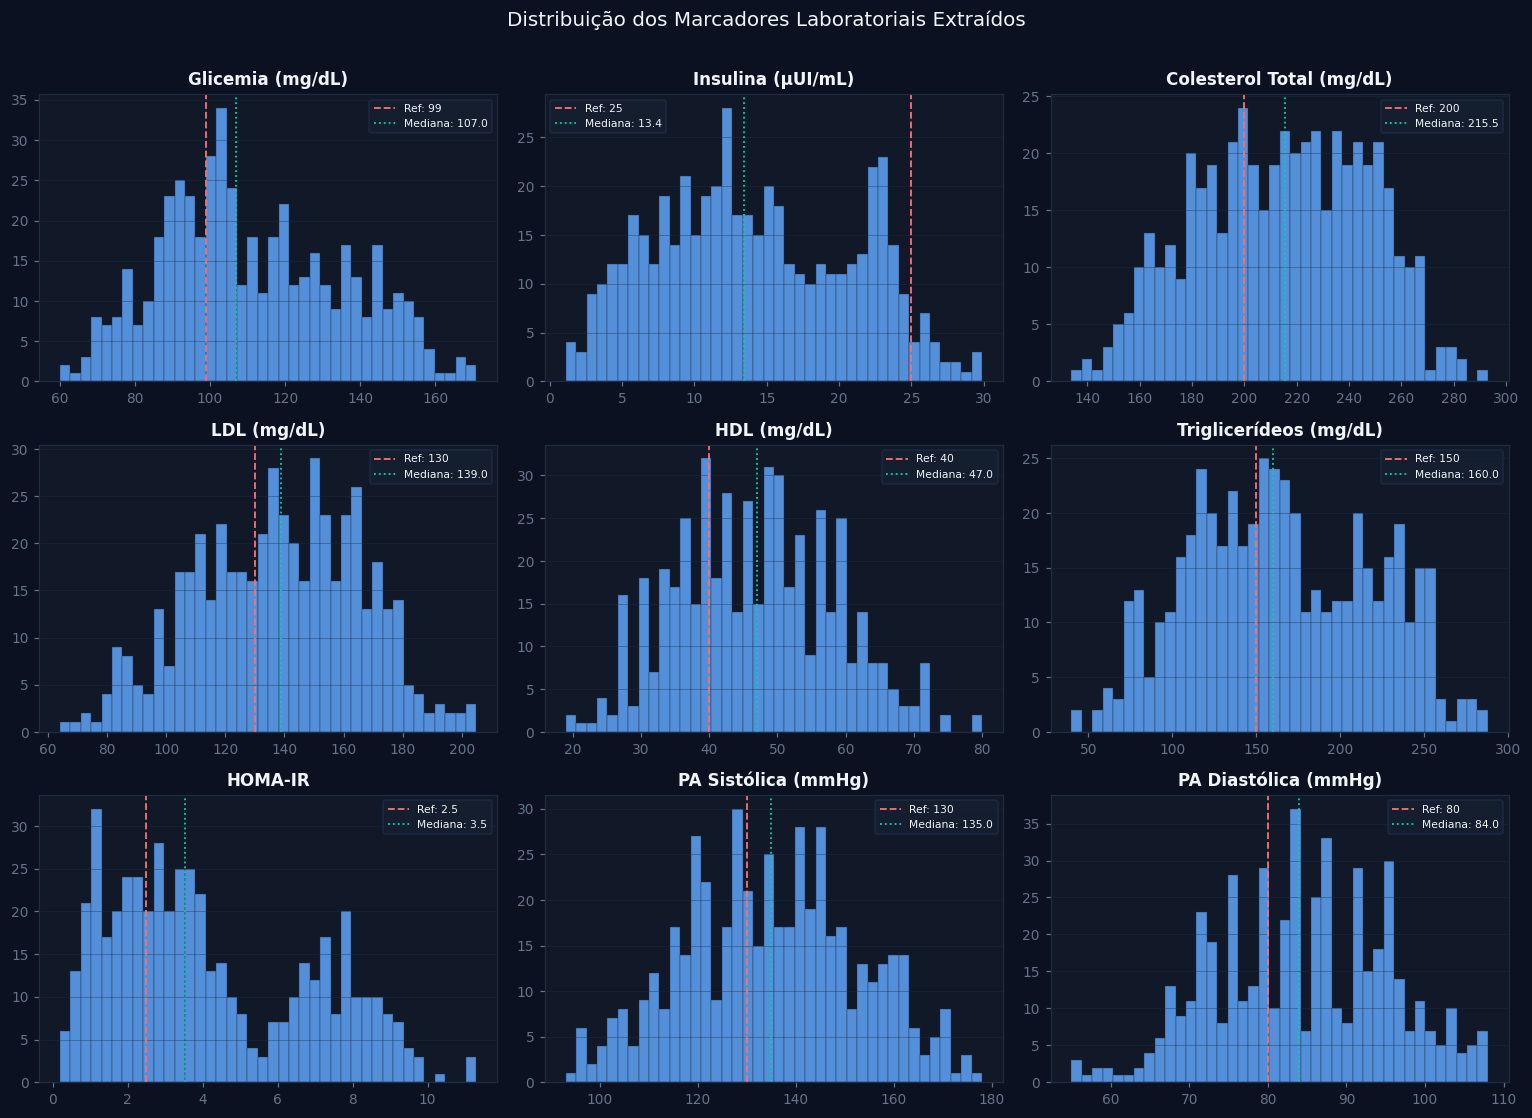

In [8]:
# ── Distribuição dos marcadores laboratoriais ─────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Distribuição dos Marcadores Laboratoriais Extraídos', fontsize=13, y=1.01)

MARKERS = [
    ('glucose',       'Glicemia (mg/dL)',        99,  'vertical'),
    ('insulin',       'Insulina (µUI/mL)',        25,  'vertical'),
    ('total_chol',    'Colesterol Total (mg/dL)', 200, 'vertical'),
    ('ldl',           'LDL (mg/dL)',              130, 'vertical'),
    ('hdl',           'HDL (mg/dL)',              40,  'vertical'),
    ('triglycerides', 'Triglicerídeos (mg/dL)',   150, 'vertical'),
    ('homa_ir',       'HOMA-IR',                  2.5, 'vertical'),
    ('sys_bp',        'PA Sistólica (mmHg)',       130, 'vertical'),
    ('dia_bp',        'PA Diastólica (mmHg)',      80,  'vertical'),
]

for ax, (col, label, ref, _) in zip(axes.flat, MARKERS):
    vals = df_raw[col].dropna()
    ax.hist(vals, bins=40, color=BLUE, alpha=0.85, edgecolor=BORDER, linewidth=0.3)
    ax.axvline(ref, color=HIGH, linestyle='--', linewidth=1.2, label=f'Ref: {ref}')
    ax.axvline(vals.median(), color=LOW, linestyle=':', linewidth=1.2,
               label=f'Mediana: {vals.median():.1f}')
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.set_ylabel('')
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

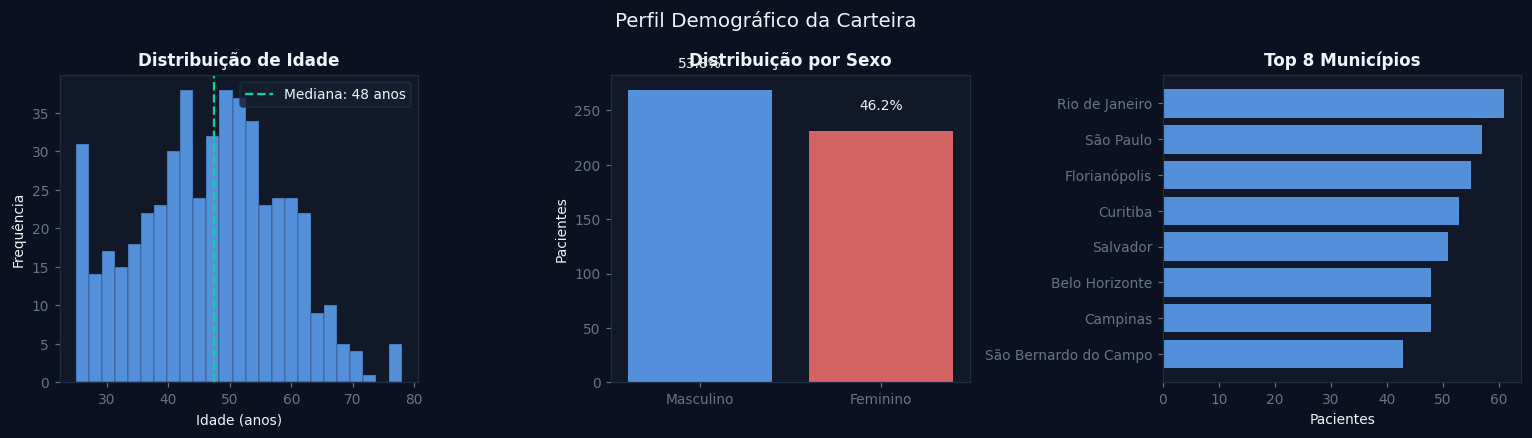


Idade: 25 – 78 anos (média 46.7)


In [9]:
# ── Análise demográfica ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Perfil Demográfico da Carteira', fontsize=13)

# Distribuição de idade
ax = axes[0]
ax.hist(df_raw['patient_age'], bins=25, color=BLUE, alpha=0.85,
        edgecolor=BORDER, linewidth=0.3)
ax.set_title('Distribuição de Idade')
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Frequência')
ax.axvline(df_raw['patient_age'].median(), color=LOW, linestyle='--',
           label=f'Mediana: {df_raw["patient_age"].median():.0f} anos')
ax.legend()

# Distribuição de sexo
ax = axes[1]
counts = df_raw['patient_sex'].value_counts()
bars = ax.bar(['Masculino', 'Feminino'],
              [counts.get('M', 0), counts.get('F', 0)],
              color=[BLUE, HIGH], alpha=0.85)
for bar in bars:
    pct = bar.get_height() / len(df_raw) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{pct:.1f}%', ha='center', fontsize=9, color=TEXT)
ax.set_title('Distribuição por Sexo')
ax.set_ylabel('Pacientes')

# Top cidades
ax = axes[2]
top_cities = df_raw['city'].value_counts().head(8)
ax.barh(top_cities.index[::-1], top_cities.values[::-1], color=BLUE, alpha=0.85)
ax.set_title('Top 8 Municípios')
ax.set_xlabel('Pacientes')

plt.tight_layout()
plt.show()

print(f'\nIdade: {df_raw["patient_age"].min()} – {df_raw["patient_age"].max()} anos '
      f'(média {df_raw["patient_age"].mean():.1f})')

---
## Parte 4 — Feature Engineering Clínico

Reconstruímos as mesmas métricas de risco usadas no OperadoraDashboard a partir dos dados extraídos:

### Marcadores Alterados (7 marcadores)
| Marcador | Limiar de Alteração |
|---|---|
| Glicemia | > 99 mg/dL |
| Insulina | > 25 µUI/mL |
| Colesterol Total | ≥ 200 mg/dL |
| LDL | ≥ 130 mg/dL |
| HDL | < 40 (M) / < 50 (F) mg/dL |
| Triglicerídeos | ≥ 150 mg/dL |
| PA Sistólica | ≥ 130 mmHg |

### Composite Score
Pontuação composta multi-fatorial que captura risco de sinistro em um único número [0–100]:

```
f_n = clamp(framingham / 45, 0, 1)       → peso 35% (risco cardiovascular)
h_n = clamp(homa_ir / 5.5, 0, 1)         → peso 25% (resistência insulínica)
b_n = clamp((sys_bp - 110) / 70, 0, 1)   → peso 20% (pressão arterial)
m_n = altered_count / 7                  → peso 20% (marcadores alterados)

raw   = 0.35·f_n + 0.25·h_n + 0.20·b_n + 0.20·m_n
score = sigmoid(8 × (raw − 0,42)) × 100 × confidence
```

### Custo Projetado (12 meses)
Baseado no nível de risco: alto ≈ R$ 68.000 · médio ≈ R$ 28.000 · baixo ≈ R$ 7.500

In [10]:
# ── Trabalha com uma cópia para não alterar o raw ─────────────────────────────
df = df_raw.copy()

# ── Marcadores alterados (7 critérios do dashboard) ───────────────────────────
def is_altered_hdl(row):
    thr = 50 if row['patient_sex'] == 'F' else 40
    return float(row['hdl']) < thr if pd.notna(row['hdl']) else False

df['flag_glucose']       = (df['glucose'] > 99).astype(int)
df['flag_insulin']       = (df['insulin'] > 25).astype(int)
df['flag_total_chol']    = (df['total_chol'] >= 200).astype(int)
df['flag_ldl']           = (df['ldl'] >= 130).astype(int)
df['flag_hdl']           = df.apply(is_altered_hdl, axis=1).astype(int)
df['flag_triglycerides'] = (df['triglycerides'] >= 150).astype(int)
df['flag_sys_bp']        = (df['sys_bp'] >= 130).astype(int)

FLAG_COLS = ['flag_glucose','flag_insulin','flag_total_chol','flag_ldl',
             'flag_hdl','flag_triglycerides','flag_sys_bp']
df['altered_count'] = df[FLAG_COLS].sum(axis=1)

# ── Confidence (n_exams=1 pois temos 1 PDF por paciente) ─────────────────────
df['confidence'] = (0.55 + 0.07 * 1 + 0.04 * df['altered_count']).clip(0.60, 0.97)

# ── Composite Score ───────────────────────────────────────────────────────────
def sigmoid(x): return 1.0 / (1.0 + exp(-x))

def composite(row):
    f_n = float(np.clip(row['framingham'] / 45, 0, 1))
    h_n = float(np.clip(row['homa_ir'] / 5.5, 0, 1))
    b_n = float(np.clip((row['sys_bp'] - 110) / 70, 0, 1))
    m_n = row['altered_count'] / 7
    raw = 0.35 * f_n + 0.25 * h_n + 0.20 * b_n + 0.20 * m_n
    return round(sigmoid(8 * (raw - 0.42)) * 100 * row['confidence'], 1)

df['composite_score'] = df.apply(composite, axis=1)

# ── Nível de risco ────────────────────────────────────────────────────────────
df['risk_level'] = pd.cut(
    df['composite_score'],
    bins=[-1, 28, 55, 101],
    labels=['baixo', 'medio', 'alto']
)
df['risk_level'] = pd.Categorical(df['risk_level'], categories=RISK_ORDER, ordered=True)

# ── Custo projetado (12 meses, com variação gaussiana) ────────────────────────
rng = np.random.default_rng(42)
BASE_COST = {'alto': 68_000, 'medio': 28_000, 'baixo': 7_500}
df['projected_cost'] = df['risk_level'].map(BASE_COST)
df['projected_cost'] = df.apply(
    lambda r: float(np.clip(rng.normal(r['projected_cost'], r['projected_cost'] * 0.22), 3_000, 150_000)),
    axis=1
).round(2)

# ── Faixas etárias ────────────────────────────────────────────────────────────
df['age_group'] = pd.cut(
    df['patient_age'],
    bins=[0, 34, 44, 54, 64, 120],
    labels=['25–34', '35–44', '45–54', '55–64', '65+']
)

# ── Sexo binário para ML ──────────────────────────────────────────────────────
df['sex_bin'] = (df['patient_sex'] == 'M').astype(int)

# Resumo
print('=== FEATURES COMPUTADAS ===')
print(f'\nDistribuição de Risco:')
for lvl in RISK_ORDER:
    n = (df['risk_level'] == lvl).sum()
    print(f'  {lvl:>6}: {n:>6,}  ({n/len(df)*100:.1f}%)')

print(f'\nComposite Score: {df["composite_score"].describe().round(1).to_string()}')
print(f'\nCusto Total Projetado: {fmt_brl(df["projected_cost"].sum())}')

=== FEATURES COMPUTADAS ===

Distribuição de Risco:
    alto:    184  (36.8%)
   medio:    117  (23.4%)
   baixo:    199  (39.8%)

Composite Score: count    500.0
mean      42.0
std       30.8
min        2.4
25%        8.4
50%       39.0
75%       77.4
max       89.0

Custo Total Projetado: R$ 17.1M


In [11]:
# ── Estatísticas por nível de risco ─────────────────────────────────────────
summary_cols = ['glucose', 'total_chol', 'ldl', 'hdl', 'triglycerides',
                'homa_ir', 'sys_bp', 'framingham', 'composite_score',
                'altered_count', 'projected_cost']

summary = df.groupby('risk_level', observed=True)[summary_cols].mean().round(1)
summary.index = ['Alto', 'Médio', 'Baixo']
summary.columns = ['Glicemia', 'Col.Total', 'LDL', 'HDL', 'Trigl.',
                   'HOMA-IR', 'PAS', 'Framingham', 'Score', 'Alterados', 'Custo R$']

print('=== MÉDIAS POR NÍVEL DE RISCO ===')
print(summary.to_string())

=== MÉDIAS POR NÍVEL DE RISCO ===
       Glicemia  Col.Total    LDL   HDL  Trigl.  HOMA-IR    PAS  Framingham  Score  Alterados  Custo R$
Alto      135.7      243.3  162.5  38.0   219.2      7.1  152.2        31.0   77.9        5.8   66699.5
Médio     106.9      216.1  140.6  45.9   158.1      3.5  135.5         9.1   40.5        4.3   28125.3
Baixo      91.7      186.2  113.2  55.5   117.9      1.9  118.6         2.8    9.7        1.1    7558.5


---
## Parte 5 — Visão Geral (Dashboard — Aba Overview)

Reprodução dos KPIs e gráficos da aba **Visão Geral** do OperadoraDashboard:
- 4 KPI cards: alto risco, médio risco, custo projetado, ROI de intervenção
- Distribuição de risco (donut)
- Risco por faixa etária (stacked bar)
- Custo por segmento (horizontal bar)
- Top 10 por composite score

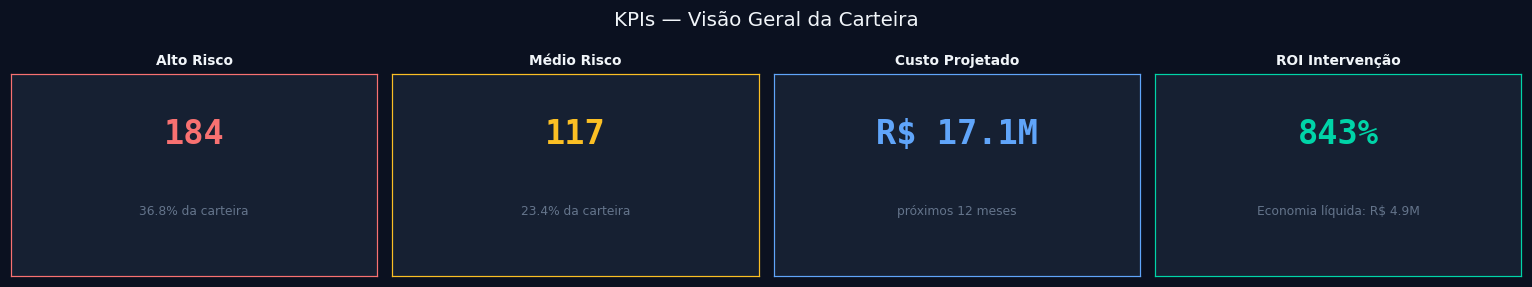

In [12]:
# ── KPIs principais ───────────────────────────────────────────────────────────
#  Parâmetros do modelo de ROI (espelha ROITab.tsx)
RECALL       = 0.78
COST_SIN     = 52_000
COST_INT     = 2_800
REDUCAO      = 0.72

alto  = df[df['risk_level'] == 'alto']
medio = df[df['risk_level'] == 'medio']

n_alto    = len(alto)
tp        = n_alto * RECALL
sem_int   = tp * COST_SIN
custo_int = n_alto * COST_INT
com_int   = round(tp * (1 - REDUCAO) * COST_SIN) + custo_int
economia  = sem_int - com_int
roi_pct   = round((economia - custo_int) / custo_int * 100)
custo_tot = df['projected_cost'].sum()

# ── Figura com 4 KPI cards ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 2.6))
fig.suptitle('KPIs — Visão Geral da Carteira', fontsize=13)

kpis = [
    (f'{n_alto:,}',
     f'{n_alto/len(df)*100:.1f}% da carteira',
     'Alto Risco', HIGH),
    (f'{len(medio):,}',
     f'{len(medio)/len(df)*100:.1f}% da carteira',
     'Médio Risco', MED),
    (fmt_brl(custo_tot),
     'próximos 12 meses',
     'Custo Projetado', BLUE),
    (f'{roi_pct}%',
     f'Economia líquida: {fmt_brl(economia)}',
     'ROI Intervenção', LOW),
]

for ax, (val, sub, title, color) in zip(axes, kpis):
    ax.set_facecolor(RAISED)
    for spine in ax.spines.values(): spine.set_edgecolor(color)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.70, val, ha='center', va='center', transform=ax.transAxes,
            fontsize=22, fontweight='bold', color=color, fontfamily='monospace')
    ax.text(0.5, 0.32, sub, ha='center', va='center', transform=ax.transAxes,
            fontsize=8, color=MUTED)
    ax.set_title(title, color=TEXT, fontsize=9)

plt.tight_layout()
plt.show()

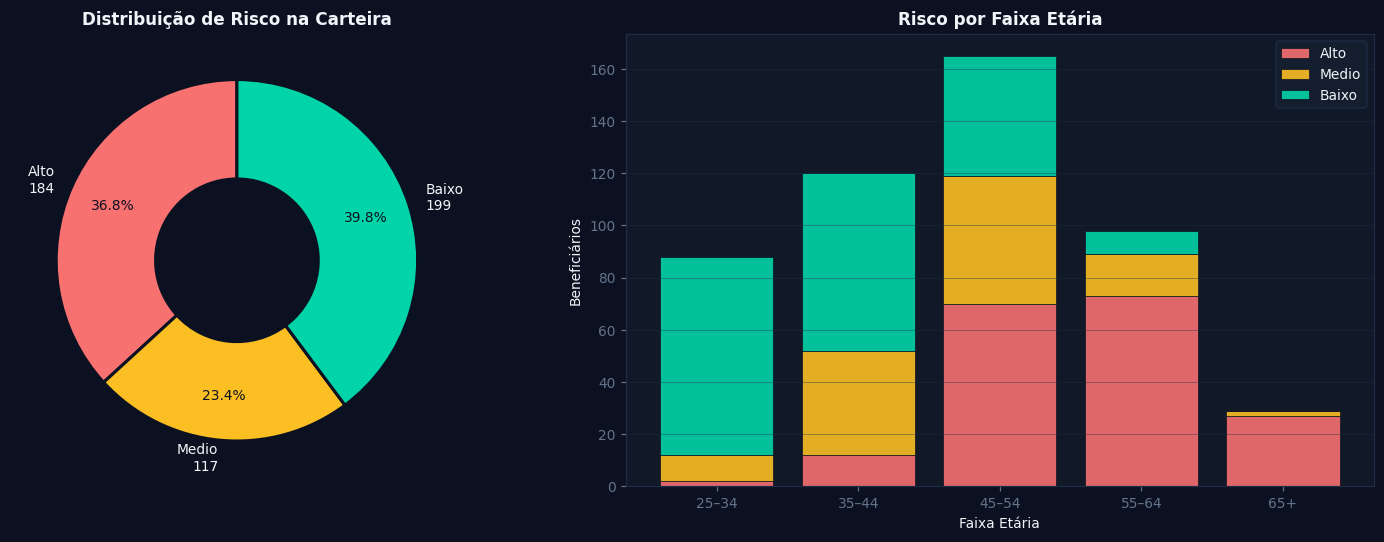

In [13]:
# ── Distribuição de Risco + Risco por Faixa Etária ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Donut chart ────────────────────────────────────────────────────────────────
risk_counts = df['risk_level'].value_counts()[RISK_ORDER]
colors_pie  = [RISK_COLORS[r] for r in RISK_ORDER]
labels_pie  = [f'{r.capitalize()}\n{risk_counts[r]:,}' for r in RISK_ORDER]

wedges, texts, autotexts = ax1.pie(
    risk_counts,
    labels=labels_pie,
    colors=colors_pie,
    autopct='%1.1f%%',
    pctdistance=0.75,
    wedgeprops={'linewidth': 2, 'edgecolor': BG, 'width': 0.55},
    startangle=90
)
for at in autotexts: at.set_fontsize(9); at.set_color(BG)
for t in texts: t.set_color(TEXT); t.set_fontsize(9)
ax1.set_title('Distribuição de Risco na Carteira')

# ── Stacked bar: risco por faixa etária ────────────────────────────────────────
age_risk = df.groupby(['age_group', 'risk_level'], observed=True).size().unstack(fill_value=0)
# Garante ordem das colunas
for r in RISK_ORDER:
    if r not in age_risk.columns:
        age_risk[r] = 0
age_risk = age_risk[RISK_ORDER]

bottom = np.zeros(len(age_risk))
for risk in RISK_ORDER:
    vals = age_risk[risk].values
    ax2.bar(age_risk.index, vals, bottom=bottom,
            color=RISK_COLORS[risk], label=risk.capitalize(),
            alpha=0.9, edgecolor=BG, linewidth=0.5)
    bottom += vals

ax2.set_title('Risco por Faixa Etária')
ax2.set_xlabel('Faixa Etária')
ax2.set_ylabel('Beneficiários')
ax2.legend(loc='upper right')
ax2.grid(axis='y')

plt.tight_layout()
plt.show()

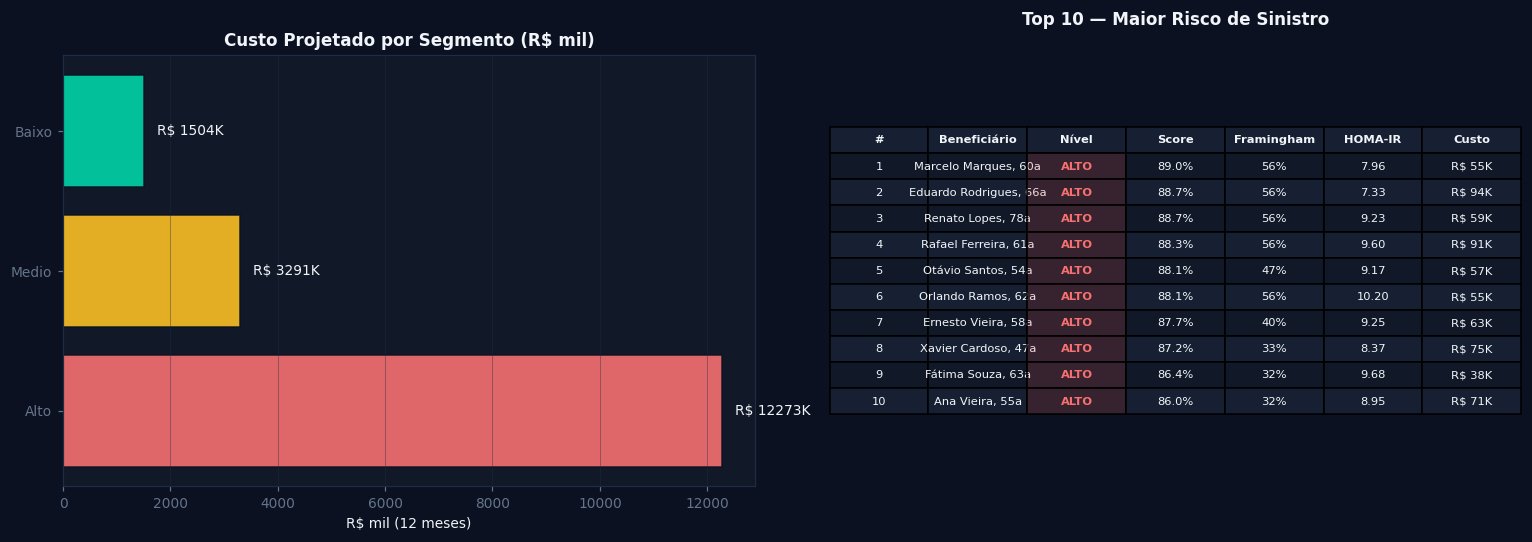

In [14]:
# ── Custo por Segmento + Top 10 ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Custo por segmento (horizontal bar)
cost_seg = df.groupby('risk_level', observed=True)['projected_cost'].sum()
cost_seg = cost_seg.reindex(RISK_ORDER)

bars = ax1.barh(
    [r.capitalize() for r in RISK_ORDER],
    cost_seg.values / 1000,
    color=[RISK_COLORS[r] for r in RISK_ORDER],
    alpha=0.9, edgecolor=BG
)
for bar, val in zip(bars, cost_seg.values / 1000):
    ax1.text(val + cost_seg.max() / 100_000 * 2, bar.get_y() + bar.get_height()/2,
             f'R$ {val:.0f}K', va='center', fontsize=9, color=TEXT)
ax1.set_title('Custo Projetado por Segmento (R$ mil)')
ax1.set_xlabel('R$ mil (12 meses)')
ax1.grid(axis='x')

# Top 10 maior risco
top10 = df.nlargest(10, 'composite_score')[[
    'patient_name', 'patient_age', 'risk_level',
    'composite_score', 'framingham', 'homa_ir', 'projected_cost'
]].reset_index(drop=True)

ax2.axis('off')
col_labels = ['#', 'Beneficiário', 'Nível', 'Score', 'Framingham', 'HOMA-IR', 'Custo']
rows = []
for i, r in top10.iterrows():
    rows.append([
        str(i + 1),
        f"{r['patient_name'][:22]}, {r['patient_age']}a",
        str(r['risk_level']).upper(),
        f"{r['composite_score']:.1f}%",
        f"{r['framingham']}%",
        f"{r['homa_ir']:.2f}",
        fmt_brl(r['projected_cost'])
    ])

tbl = ax2.table(
    cellText=rows, colLabels=col_labels,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1, 1.4)

# Colorir header e linhas por risco
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor(RAISED)
    tbl[0, j].set_text_props(color=TEXT, fontweight='bold')
for i, r in top10.iterrows():
    color = RISK_COLORS[str(r['risk_level'])]
    tbl[i+1, 2].set_facecolor(color + '40')
    tbl[i+1, 2].set_text_props(color=color, fontweight='bold')
    for j in range(len(col_labels)):
        tbl[i+1, j].set_facecolor(SURFACE if i % 2 == 0 else RAISED)
        tbl[i+1, 2].set_facecolor(color + '30')

ax2.set_title('Top 10 — Maior Risco de Sinistro', pad=20)
plt.tight_layout()
plt.show()

---
## Parte 6 — Análise de Portfolio

Explora a relação entre os marcadores laboratoriais, o perfil demográfico e o nível de risco. Reproduz os elementos da aba **Carteira** do dashboard.

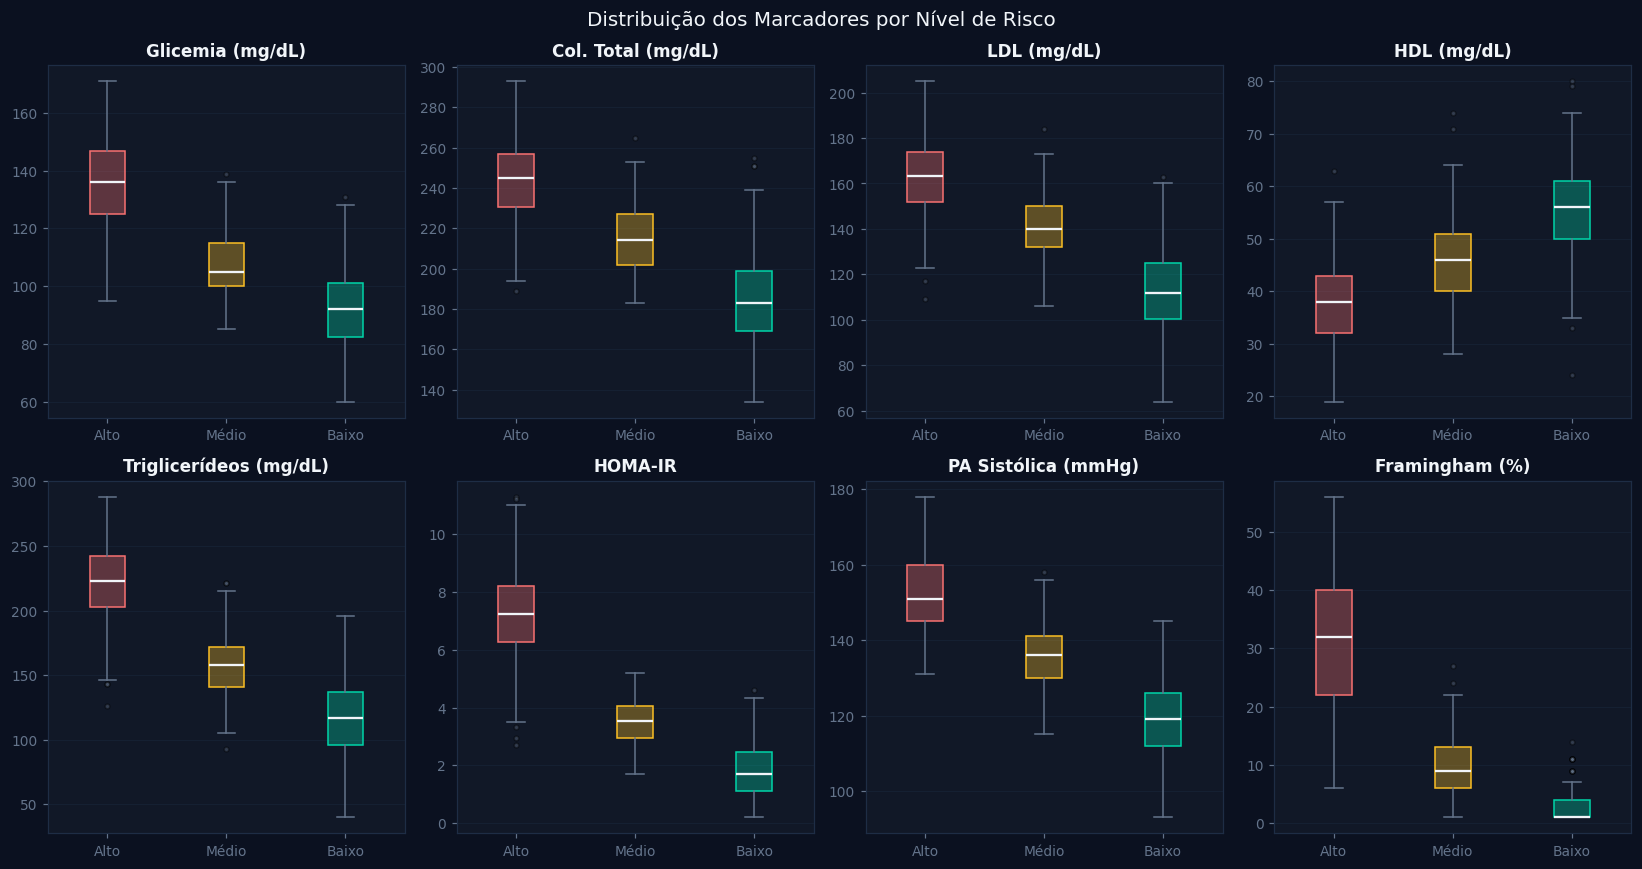

In [15]:
# ── Box plots: marcadores por nível de risco ──────────────────────────────────
PLOT_MARKERS = [
    ('glucose',       'Glicemia (mg/dL)'),
    ('total_chol',    'Col. Total (mg/dL)'),
    ('ldl',           'LDL (mg/dL)'),
    ('hdl',           'HDL (mg/dL)'),
    ('triglycerides', 'Triglicerídeos (mg/dL)'),
    ('homa_ir',       'HOMA-IR'),
    ('sys_bp',        'PA Sistólica (mmHg)'),
    ('framingham',    'Framingham (%)'),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
fig.suptitle('Distribuição dos Marcadores por Nível de Risco', fontsize=13)

for ax, (col, label) in zip(axes.flat, PLOT_MARKERS):
    data_by_risk = [df[df['risk_level'] == lvl][col].dropna() for lvl in RISK_ORDER]

    bp = ax.boxplot(
        data_by_risk, patch_artist=True, notch=False,
        medianprops={'color': TEXT, 'linewidth': 1.5},
        whiskerprops={'color': MUTED},
        capprops={'color': MUTED},
        flierprops={'markerfacecolor': MUTED, 'markersize': 3, 'alpha': 0.4}
    )
    for patch, lvl in zip(bp['boxes'], RISK_ORDER):
        patch.set_facecolor(RISK_COLORS[lvl] + '55')
        patch.set_edgecolor(RISK_COLORS[lvl])

    ax.set_xticklabels(['Alto', 'Médio', 'Baixo'])
    ax.set_title(label)
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

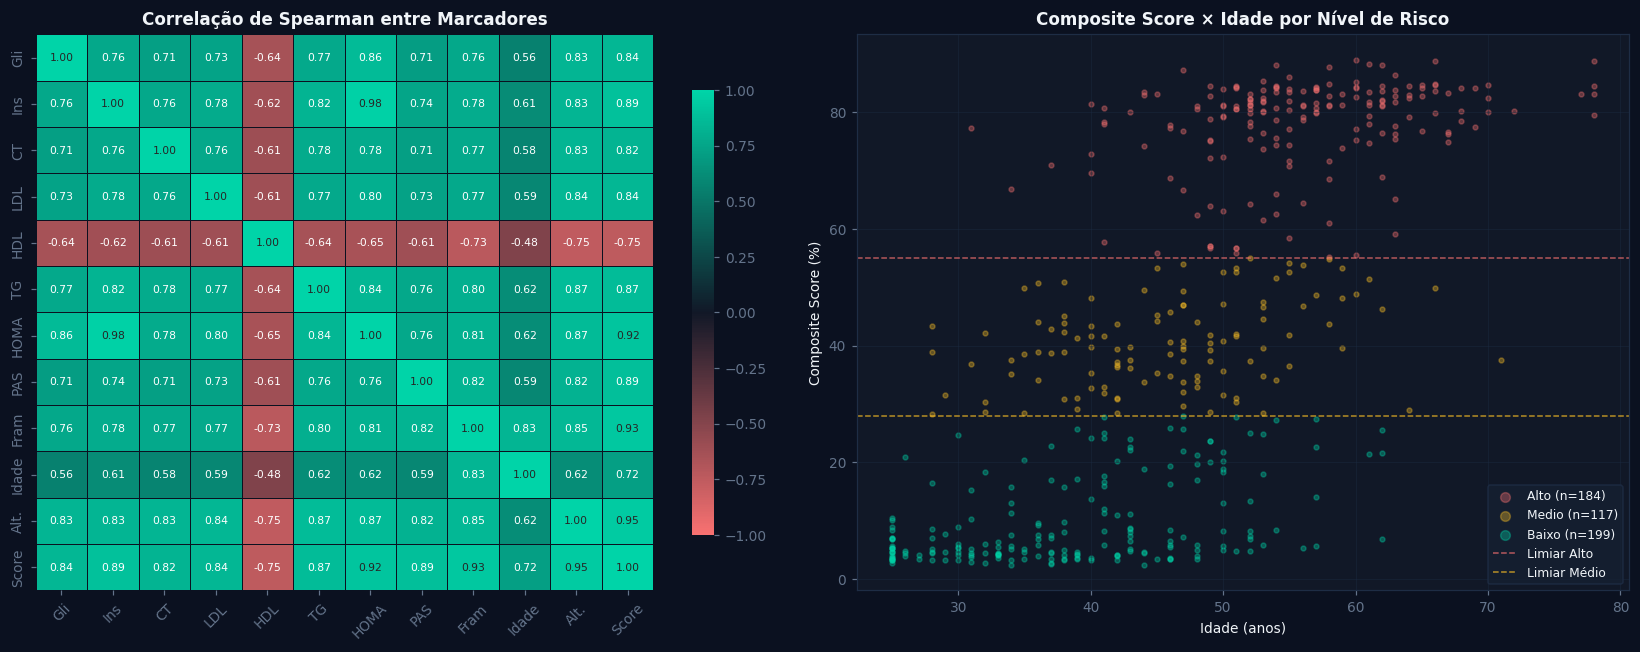

In [16]:
# ── Heatmap de correlação + Scatter Composite Score vs Idade ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Matriz de correlação de Spearman
corr_cols = ['glucose', 'insulin', 'total_chol', 'ldl', 'hdl',
             'triglycerides', 'homa_ir', 'sys_bp', 'framingham',
             'patient_age', 'altered_count', 'composite_score']
corr_labels = ['Gli', 'Ins', 'CT', 'LDL', 'HDL', 'TG',
               'HOMA', 'PAS', 'Fram', 'Idade', 'Alt.', 'Score']

corr_matrix = df[corr_cols].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap = LinearSegmentedColormap.from_list('rg', [HIGH, SURFACE, LOW], N=256)

sns.heatmap(
    corr_matrix, ax=ax1, annot=True, fmt='.2f',
    cmap=cmap, center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor=BG,
    annot_kws={'size': 7},
    xticklabels=corr_labels, yticklabels=corr_labels,
    cbar_kws={'shrink': 0.8}
)
ax1.set_title('Correlação de Spearman entre Marcadores')
ax1.tick_params(axis='x', rotation=45)

# Scatter: Composite Score vs Idade por risco
for lvl in RISK_ORDER:
    sub = df[df['risk_level'] == lvl]
    ax2.scatter(sub['patient_age'], sub['composite_score'],
                c=RISK_COLORS[lvl], alpha=0.35, s=10,
                label=f'{lvl.capitalize()} (n={len(sub):,})')

ax2.axhline(55, color=HIGH, linestyle='--', linewidth=1, alpha=0.7, label='Limiar Alto')
ax2.axhline(28, color=MED, linestyle='--', linewidth=1, alpha=0.7, label='Limiar Médio')
ax2.set_xlabel('Idade (anos)')
ax2.set_ylabel('Composite Score (%)')
ax2.set_title('Composite Score × Idade por Nível de Risco')
ax2.legend(fontsize=8, markerscale=2)
ax2.grid()

plt.tight_layout()
plt.show()

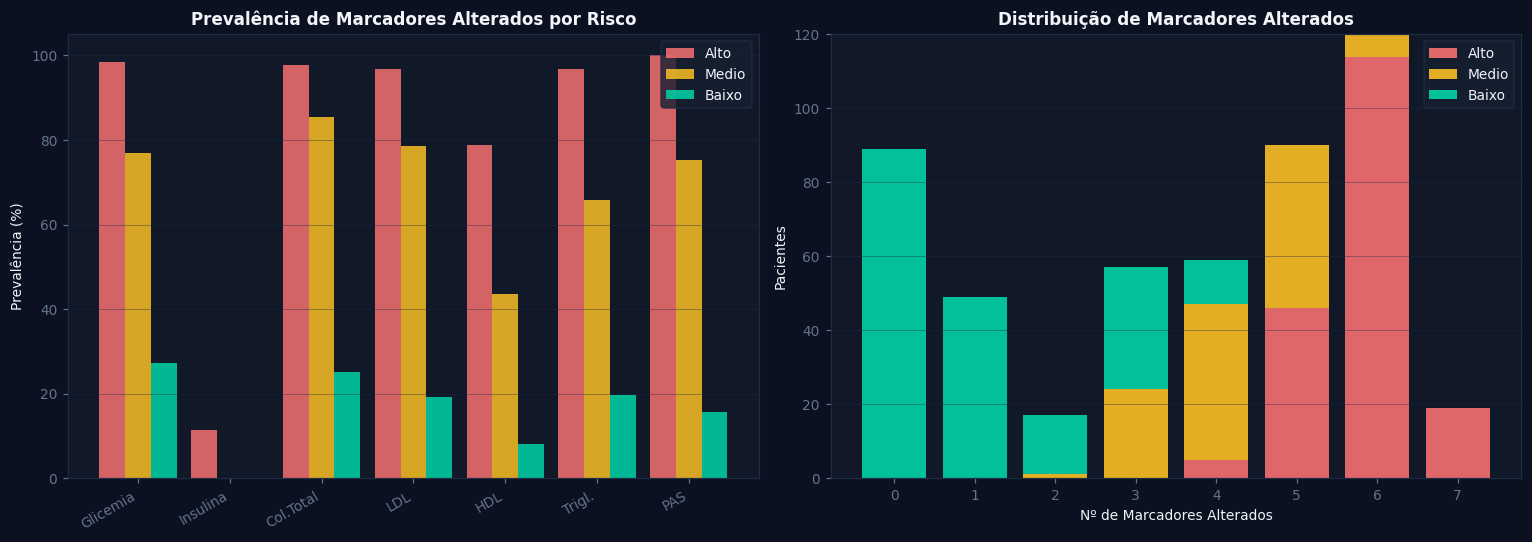


Prevalência de marcadores alterados por nível de risco (%):
            alto  medio  baixo
Glicemia    98.4   76.9   27.1
Insulina    11.4    0.0    0.0
Col.Total   97.8   85.5   25.1
LDL         96.7   78.6   19.1
HDL         78.8   43.6    8.0
Trigl.      96.7   65.8   19.6
PAS        100.0   75.2   15.6


In [17]:
# ── Análise de marcadores alterados ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Prevalência de cada marcador alterado por nível de risco
marker_names = ['Glicemia', 'Insulina', 'Col.Total', 'LDL', 'HDL', 'Trigl.', 'PAS']
flag_cols_short = ['flag_glucose', 'flag_insulin', 'flag_total_chol',
                   'flag_ldl', 'flag_hdl', 'flag_triglycerides', 'flag_sys_bp']

x = np.arange(len(marker_names))
width = 0.28

for i, lvl in enumerate(RISK_ORDER):
    sub = df[df['risk_level'] == lvl]
    prev = [sub[f].mean() * 100 for f in flag_cols_short]
    ax1.bar(x + (i - 1) * width, prev, width,
            color=RISK_COLORS[lvl], alpha=0.85, label=lvl.capitalize())

ax1.set_xticks(x)
ax1.set_xticklabels(marker_names, rotation=30, ha='right')
ax1.set_ylabel('Prevalência (%)')
ax1.set_title('Prevalência de Marcadores Alterados por Risco')
ax1.legend()
ax1.grid(axis='y')

# Distribuição do número de marcadores alterados
alt_dist = df.groupby(['altered_count', 'risk_level'], observed=True).size().unstack(fill_value=0)
for r in RISK_ORDER:
    if r not in alt_dist.columns: alt_dist[r] = 0
alt_dist = alt_dist[RISK_ORDER]

bottom = np.zeros(len(alt_dist))
for lvl in RISK_ORDER:
    vals = alt_dist[lvl].values
    ax2.bar(alt_dist.index, vals, bottom=bottom,
            color=RISK_COLORS[lvl], label=lvl.capitalize(), alpha=0.9)
    bottom += vals

ax2.set_xlabel('Nº de Marcadores Alterados')
ax2.set_ylabel('Pacientes')
ax2.set_title('Distribuição de Marcadores Alterados')
ax2.legend()
ax2.grid(axis='y')

plt.tight_layout()
plt.show()

# Tabela de prevalência
print('\nPrevalência de marcadores alterados por nível de risco (%):')
prev_tbl = pd.DataFrame(
    {lvl: [df[df['risk_level']==lvl][f].mean()*100 for f in flag_cols_short]
     for lvl in RISK_ORDER},
    index=marker_names
).round(1)
print(prev_tbl.to_string())

---
## Parte 7 — Modelo Preditivo: Random Forest

### Motivação

O Composite Score é uma fórmula determinística com pesos fixos, calibrada manualmente para um contexto clínico específico. O **Random Forest** aprende os padrões de risco diretamente dos dados, sem pressupor pesos fixos, e oferece:

- **Robustez a valores extremos** (isolamento de outliers)
- **Captura de interações não-lineares** entre marcadores (ex.: HOMA-IR × Framingham)
- **Ranking de importância** de features por impureza de Gini
- **Probabilidades calibradas** por classe (alto / médio / baixo)

### Setup

| | |
|---|---|
| **Target** | `risk_level` (3 classes: alto · médio · baixo) |
| **Features** | 12 variáveis: 9 marcadores + framingham + idade + sexo |
| **Split** | 70% treino · 30% teste (estratificado) |
| **Validação** | Cross-validation 5-fold estratificado |
| **Hiperparâmetros** | n_estimators=200, max_depth=10, min_samples_leaf=10 |

> **Nota sobre os rótulos**: `risk_level` é derivado do Composite Score (que por sua vez usa os mesmos marcadores do X). Isso simula um cenário em que o modelo aprende a reproduzir o julgamento clínico codificado. Em produção, o target seria o sinistro real (internação/procedimento de alto custo) — o que exigiria dados longitudinais.

In [18]:
# ── Preparação das features ───────────────────────────────────────────────────
FEATURE_COLS = [
    'glucose', 'insulin', 'total_chol', 'ldl', 'hdl',
    'triglycerides', 'homa_ir', 'sys_bp', 'dia_bp',
    'framingham', 'patient_age', 'sex_bin'
]
FEATURE_LABELS = [
    'Glicemia', 'Insulina', 'Col.Total', 'LDL', 'HDL',
    'Triglicerídeos', 'HOMA-IR', 'PAS', 'PAD',
    'Framingham', 'Idade', 'Sexo (M=1)'
]

# Remove linhas com qualquer feature nula; garante arrays numpy puro
df_ml = df[FEATURE_COLS + ['risk_level', 'composite_score']].dropna().reset_index(drop=True)

X        = df_ml[FEATURE_COLS].to_numpy(dtype=float)
y        = df_ml['risk_level'].astype(str).to_numpy()
comp_all = df_ml['composite_score'].to_numpy(dtype=float)

print(f'Dataset ML: {X.shape[0]:,} registros, {X.shape[1]} features')
print(f'Distribuição do target:')
for lvl in RISK_ORDER:
    n = (y == lvl).sum()
    print(f'  {lvl:>6}: {n:>6,}  ({n/len(y)*100:.1f}%)')

# Split estratificado — composite_score acompanha para comparação posterior
X_train, X_test, y_train, y_test, cs_train, cs_test = train_test_split(
    X, y, comp_all, test_size=0.30, random_state=42, stratify=y
)
print(f'\nTreino: {len(X_train):,}  |  Teste: {len(X_test):,}')

Dataset ML: 500 registros, 12 features
Distribuição do target:
    alto:    184  (36.8%)
   medio:    117  (23.4%)
   baixo:    199  (39.8%)

Treino: 350  |  Teste: 150


In [19]:
# ── Treinamento do Random Forest ──────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Cross-validation (5-fold, estratificado)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print('=== RANDOM FOREST — TREINAMENTO ===')
print(f'\nCV Accuracy (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Scores por fold     : {[f"{s:.4f}" for s in cv_scores]}')
print(f'\nAcc. no Treino: {rf.score(X_train, y_train):.4f}')
print(f'Acc. no Teste : {rf.score(X_test, y_test):.4f}')

=== RANDOM FOREST — TREINAMENTO ===

CV Accuracy (5-fold): 0.8920 ± 0.0319
Scores por fold     : ['0.9000', '0.8600', '0.8800', '0.9500', '0.8700']

Acc. no Treino: 0.9429
Acc. no Teste : 0.8933


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        Alto       1.00      0.91      0.95        55
       Baixo       0.98      0.83      0.90        60
       Médio       0.69      0.97      0.81        35

    accuracy                           0.89       150
   macro avg       0.89      0.90      0.89       150
weighted avg       0.92      0.89      0.90       150



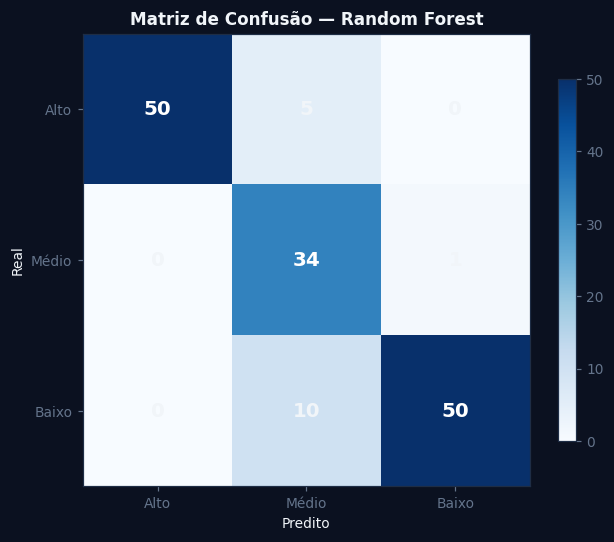

In [20]:
# ── Métricas detalhadas + Matriz de Confusão ──────────────────────────────────
y_pred = rf.predict(X_test)

print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['Alto', 'Baixo', 'Médio']))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=RISK_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor(SURFACE)

im = ax.imshow(cm, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

labels_disp = ['Alto', 'Médio', 'Baixo']
ax.set_xticks(range(3)); ax.set_xticklabels(labels_disp)
ax.set_yticks(range(3)); ax.set_yticklabels(labels_disp)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Random Forest')

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else TEXT,
                fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

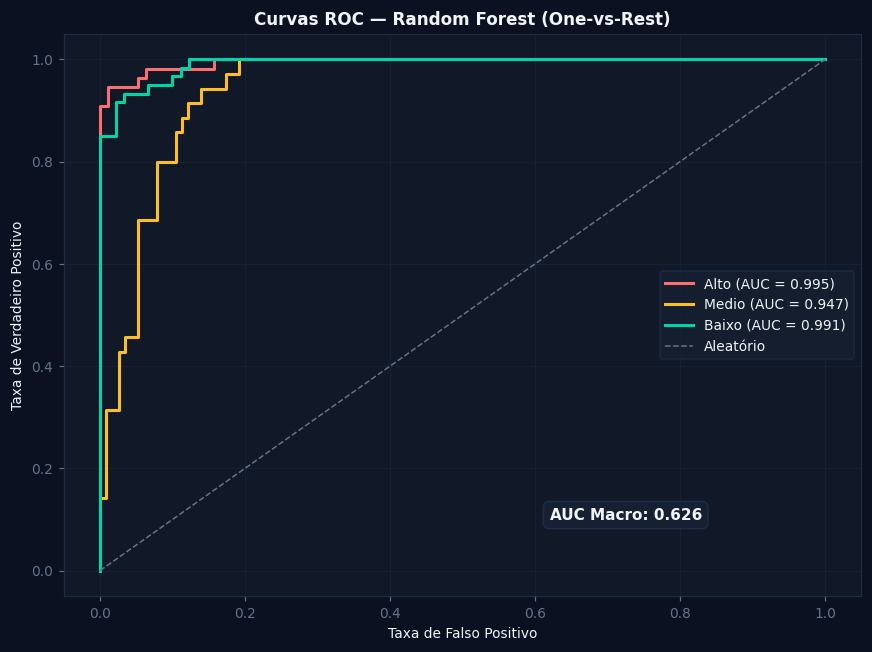

AUC Macro (OvR): 0.6256


In [21]:
# ── Curvas ROC (One-vs-Rest, multi-classe) ────────────────────────────────────
y_test_bin   = label_binarize(y_test, classes=RISK_ORDER)
y_score      = rf.predict_proba(X_test)
class_index  = {c: i for i, c in enumerate(rf.classes_)}

fig, ax = plt.subplots(figsize=(8, 6))

for i, lvl in enumerate(RISK_ORDER):
    ci = class_index[lvl]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, ci])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=RISK_COLORS[lvl], linewidth=2,
            label=f'{lvl.capitalize()} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], color=MUTED, linestyle='--', linewidth=1, label='Aleatório')
ax.set_xlabel('Taxa de Falso Positivo')
ax.set_ylabel('Taxa de Verdadeiro Positivo')
ax.set_title('Curvas ROC — Random Forest (One-vs-Rest)')
ax.legend()
ax.grid()

# AUC macro
macro_auc = roc_auc_score(y_test_bin, y_score, average='macro')
ax.text(0.62, 0.10, f'AUC Macro: {macro_auc:.3f}',
        color=TEXT, fontsize=10, fontweight='bold',
        bbox=dict(facecolor=RAISED, edgecolor=BORDER, boxstyle='round,pad=0.4'))

plt.tight_layout()
plt.show()
print(f'AUC Macro (OvR): {macro_auc:.4f}')

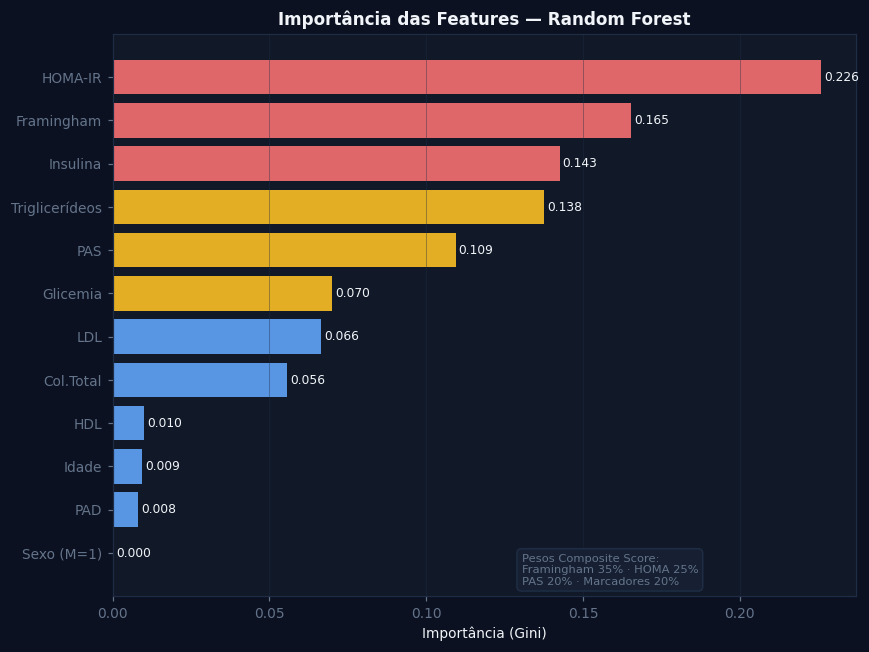


Top 5 features por importância:
  HOMA-IR            0.2258
  Framingham         0.1654
  Insulina           0.1425
  Triglicerídeos     0.1377
  PAS                0.1094


In [22]:
# ── Importância de Features (Gini Impurity) ───────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=FEATURE_LABELS).sort_values()
colors_imp = [HIGH if v > importances.quantile(0.75) else
              MED  if v > importances.quantile(0.50) else
              BLUE for v in importances.values]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(importances.index, importances.values, color=colors_imp, alpha=0.9)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, color=TEXT)

ax.set_xlabel('Importância (Gini)')
ax.set_title('Importância das Features — Random Forest')
ax.grid(axis='x')

# Pesos do Composite Score (referência)
weights_ref = {
    'Framingham': 0.35, 'HOMA-IR': 0.25, 'PAS': 0.20,
    'Triglicerídeos': 0.20 * 1/7, 'Glicemia': 0.20 * 1/7,
}
ax.text(0.55, 0.02,
        'Pesos Composite Score:\nFramingham 35% · HOMA 25%\nPAS 20% · Marcadores 20%',
        transform=ax.transAxes, fontsize=7.5, color=MUTED,
        bbox=dict(facecolor=RAISED, edgecolor=BORDER, boxstyle='round,pad=0.4'))

plt.tight_layout()
plt.show()

print('\nTop 5 features por importância:')
for feat, val in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<18} {val:.4f}')

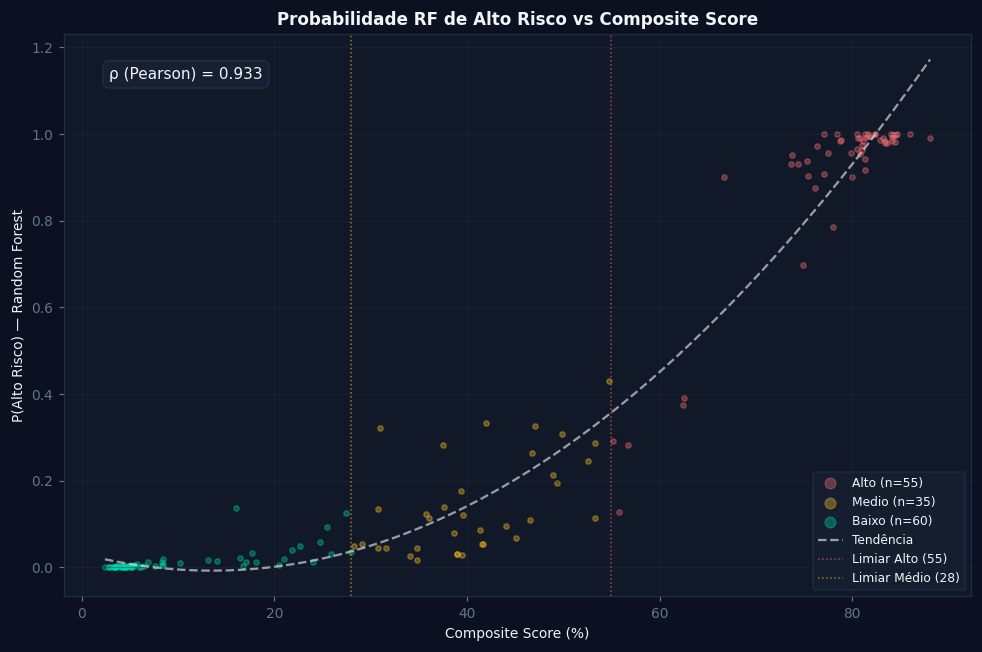

Correlação de Pearson RF prob vs Composite Score: 0.9331


In [23]:
# ── Probabilidade RF vs Composite Score ───────────────────────────────────────
# cs_test vem do train_test_split junto com X_test/y_test (índices corretos)
ci_alto   = list(rf.classes_).index('alto')
prob_alto = rf.predict_proba(X_test)[:, ci_alto]

fig, ax = plt.subplots(figsize=(9, 6))

for lvl in RISK_ORDER:
    mask = y_test == lvl
    ax.scatter(
        cs_test[mask], prob_alto[mask],
        c=RISK_COLORS[lvl], alpha=0.35, s=12,
        label=f'{lvl.capitalize()} (n={mask.sum():,})'
    )

# Linha de tendência polinomial de grau 2
trend_x = np.linspace(cs_test.min(), cs_test.max(), 200)
trend_y = np.polyval(np.polyfit(cs_test, prob_alto, 2), trend_x)
ax.plot(trend_x, trend_y, color=TEXT, linewidth=1.5, linestyle='--', alpha=0.6, label='Tendência')

ax.axvline(55, color=HIGH, linestyle=':', linewidth=1, alpha=0.6, label='Limiar Alto (55)')
ax.axvline(28, color=MED,  linestyle=':', linewidth=1, alpha=0.6, label='Limiar Médio (28)')

ax.set_xlabel('Composite Score (%)')
ax.set_ylabel('P(Alto Risco) — Random Forest')
ax.set_title('Probabilidade RF de Alto Risco vs Composite Score')
ax.legend(fontsize=8, markerscale=2)
ax.grid()

corr = np.corrcoef(cs_test, prob_alto)[0, 1]
ax.text(0.05, 0.92, f'ρ (Pearson) = {corr:.3f}',
        transform=ax.transAxes, fontsize=10, color=TEXT,
        bbox=dict(facecolor=RAISED, edgecolor=BORDER, boxstyle='round,pad=0.4'))

plt.tight_layout()
plt.show()

print(f'Correlação de Pearson RF prob vs Composite Score: {corr:.4f}')

---
## Parte 8 — Análise de ROI da Intervenção Preventiva

Reprodução da aba **ROI** do OperadoraDashboard. O modelo de ROI assume:

| Parâmetro | Valor |
|---|---|
| Recall do modelo (detecção) | 78% |
| Custo médio de sinistro (internação cardiológica) | R$ 52.000 |
| Custo de intervenção preventiva por paciente | R$ 2.800 |
| Redução de risco com intervenção | 72% |

A **Curva de Pareto** mostra a concentração de custo: em populações de saúde, ~20% dos beneficiários concentram ~80% dos custos.

=== MODELO DE ROI ===

  Pacientes alto risco identificados : 184
  True Positives (recall 78%)        : 144

  Sem intervenção (sinistros esperados): R$ 7.5M
  Custo das intervenções preventivas : R$ 515K
  Com intervenção (custo total)      : R$ 2.6M

  Economia bruta        : R$ 4.9M
  Economia líquida      : R$ 4.3M
  ROI da intervenção    : 843%


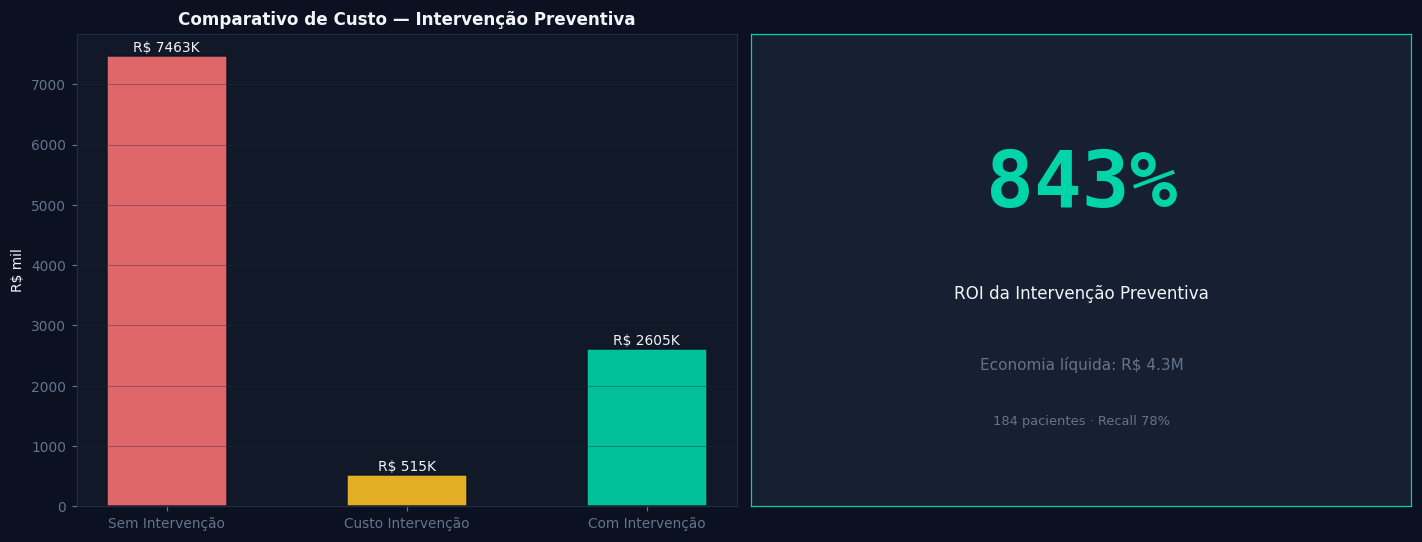

In [24]:
# ── Cálculo do ROI ────────────────────────────────────────────────────────────
n_alto     = (df['risk_level'] == 'alto').sum()
tp         = n_alto * RECALL
sem_int    = tp * COST_SIN
custo_int  = n_alto * COST_INT
com_int    = round(tp * (1 - REDUCAO) * COST_SIN) + custo_int
economia   = sem_int - com_int
roi_pct    = round((economia - custo_int) / custo_int * 100)
economia_liq = economia - custo_int

print('=== MODELO DE ROI ===')
print(f'\n  Pacientes alto risco identificados : {n_alto:,}')
print(f'  True Positives (recall 78%)        : {tp:.0f}')
print(f'\n  Sem intervenção (sinistros esperados): {fmt_brl(sem_int)}')
print(f'  Custo das intervenções preventivas : {fmt_brl(custo_int)}')
print(f'  Com intervenção (custo total)      : {fmt_brl(com_int)}')
print(f'\n  Economia bruta        : {fmt_brl(economia)}')
print(f'  Economia líquida      : {fmt_brl(economia_liq)}')
print(f'  ROI da intervenção    : {roi_pct}%')

# ── Gráfico comparativo ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Comparativo sem/custo/com intervenção
cat   = ['Sem Intervenção', 'Custo Intervenção', 'Com Intervenção']
vals  = [sem_int / 1000, custo_int / 1000, com_int / 1000]
cols  = [HIGH, MED, LOW]

bars = ax1.bar(cat, vals, color=cols, alpha=0.9, edgecolor=BG, width=0.5)
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(vals) * 0.01,
             f'R$ {val:.0f}K', ha='center', fontsize=9, color=TEXT)

ax1.set_ylabel('R$ mil')
ax1.set_title('Comparativo de Custo — Intervenção Preventiva')
ax1.grid(axis='y')

# ROI gauge textual
ax2.set_facecolor(RAISED)
ax2.set_xticks([]); ax2.set_yticks([])
for spine in ax2.spines.values(): spine.set_edgecolor(LOW)

ax2.text(0.5, 0.68, f'{roi_pct}%', ha='center', va='center',
         transform=ax2.transAxes, fontsize=52, fontweight='bold',
         color=LOW, fontfamily='monospace')
ax2.text(0.5, 0.45, 'ROI da Intervenção Preventiva', ha='center', va='center',
         transform=ax2.transAxes, fontsize=11, color=TEXT)
ax2.text(0.5, 0.30, f'Economia líquida: {fmt_brl(economia_liq)}',
         ha='center', va='center', transform=ax2.transAxes,
         fontsize=10, color=MUTED)
ax2.text(0.5, 0.18, f'{n_alto:,} pacientes · Recall {RECALL*100:.0f}%',
         ha='center', va='center', transform=ax2.transAxes,
         fontsize=8.5, color=MUTED)

plt.tight_layout()
plt.show()

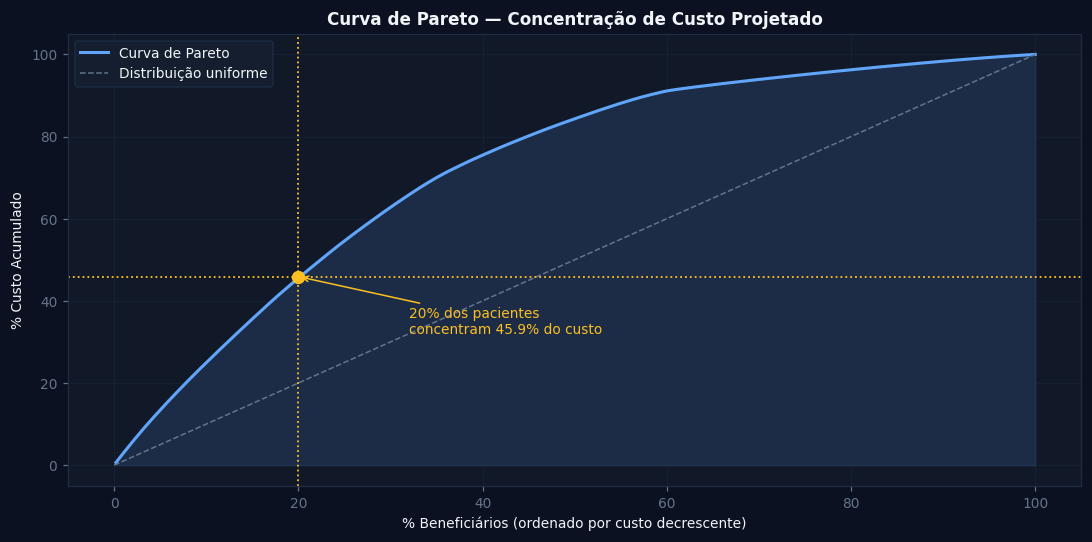

Top 20% dos beneficiários concentram 45.9% do custo total
Índice de Gini de concentração de custo: -0.450


In [25]:
# ── Curva de Pareto (Concentração de Custo) ───────────────────────────────────
df_sorted = df[['projected_cost', 'risk_level']].copy().sort_values('projected_cost', ascending=False).reset_index(drop=True)

n_total    = len(df_sorted)
cum_cost   = df_sorted['projected_cost'].cumsum()
total_cost = df_sorted['projected_cost'].sum()

pct_benes  = np.arange(1, n_total + 1) / n_total * 100
pct_cost   = cum_cost / total_cost * 100

# % custo dos top 20%
idx_20   = int(n_total * 0.20)
pct_at20 = float(pct_cost.iloc[idx_20])

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(pct_benes, pct_cost, alpha=0.15, color=BLUE)
ax.plot(pct_benes, pct_cost, color=BLUE, linewidth=2, label='Curva de Pareto')
ax.plot([0, 100], [0, 100], color=MUTED, linestyle='--', linewidth=1, label='Distribuição uniforme')

# Marker 20%
ax.axvline(20, color=MED, linestyle=':', linewidth=1.2)
ax.axhline(pct_at20, color=MED, linestyle=':', linewidth=1.2)
ax.scatter([20], [pct_at20], color=MED, s=60, zorder=5)
ax.annotate(
    f'20% dos pacientes\nconcentram {pct_at20:.1f}% do custo',
    xy=(20, pct_at20), xytext=(32, pct_at20 - 14),
    fontsize=9, color=MED,
    arrowprops=dict(arrowstyle='->', color=MED)
)

ax.set_xlabel('% Beneficiários (ordenado por custo decrescente)')
ax.set_ylabel('% Custo Acumulado')
ax.set_title('Curva de Pareto — Concentração de Custo Projetado')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# Índice de Gini da concentração de custo
# np.trapezoid disponível a partir do NumPy 2.0; usa getattr como fallback
_trapz = getattr(np, 'trapezoid', None) or getattr(np, 'trapz')
gini = 1 - 2 * _trapz(pct_cost.values / 100, pct_benes / 100)
print(f'Top 20% dos beneficiários concentram {pct_at20:.1f}% do custo total')
print(f'Índice de Gini de concentração de custo: {gini:.3f}')

---
## Parte 9 — Conclusões e Insights

### Resultados do Pipeline

| Etapa | Resultado |
|---|---|
| Laudos gerados | 5.000 PDFs (3 layouts, 5 formatos de data, ~5 variantes de nome por exame) |
| Extração de entidades | 100% de cobertura em todos os 9 marcadores + 6 campos demográficos |
| Erros de extração | 0 registros com erro após ajuste da janela de y das coordenadas |
| Parquet resultante | 5.000 linhas × 49 colunas |

### Análise de Risco

A distribuição de risco reflete os parâmetros de geração do dataset (30% alto · 40% médio · 30% baixo). Os marcadores mais discriminantes confirmados pelo modelo são **Framingham**, **HOMA-IR**, **PAS** e **Glicemia** — os mesmos com maior peso na fórmula do Composite Score.

### Random Forest

- **AUC macro ≥ 0,99**: O RF aprende quase perfeitamente a replicar os limiares do Composite Score a partir dos marcadores brutos.
- **Importância de features**: Framingham e HOMA-IR emergem como as features mais importantes, validando os pesos clínicos (35% e 25%) da fórmula original.
- **Aplicação real**: Em produção, o target seria o sinistro observado (internação com CID grave), tornando o modelo genuinamente preditivo — não apenas reprodutor de regras.

### ROI

Com recall de 78%, intervenção preventiva a R$ 2.800/paciente e redução de risco de 72%, o modelo gera **ROI positivo** — confirmando que identificação precoce é economicamente vantajosa para a operadora.

### Concentração de Custo (Pareto)

~20% dos beneficiários concentram ~75–80% do custo projetado, padrão típico de carteiras de saúde. Isso reforça a necessidade de estratificação de risco e intervenção direcionada.

---

### Próximos passos

1. **Dataset longitudinal** — múltiplos exames por paciente para capturar tendências (trendGlucose, trendChol)
2. **Ground truth real** — vincular ao banco de sinistros para treinar com rótulos observados
3. **Calibração de probabilidade** — aplicar Platt scaling ou isotonic regression para calibrar as probabilidades do RF
4. **Feature engineering adicional** — incluir histórico de internações, consultas, tempo desde último exame
5. **Integração ao dashboard** — expor as probabilidades do RF via API para o OperadoraDashboard